# Task 3 GNN BERT Fusion for Multi Context Understanding

Goal

Use FMA medium to combine audio structure graphs with semantic metadata text.

The notebook predicts top level genre and multiple music tags.

Four required models are compared:

BERT only.

GNN only.

Early concatenation.

Cross attention fusion.

All useful results are saved into one GitHub ready folder.

Large raw graph caches are kept outside the download folder.

Model weight files are not saved.

In [1]:
# ============================================================
# CELL 1 - INSTALL
# ============================================================
!pip -q install torch-geometric transformers==4.46.3 librosa==0.10.2.post1 soundfile joblib networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 94.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.1/260.1 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.9 MB/s eta 0:00:00:00:01


In [2]:
# ============================================================
# CELL 2 - IMPORTS
# ============================================================
import os, sys, gc, re, ast, html, json, math, time, random, shutil
import warnings, subprocess, tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import joblib

import librosa
import librosa.display
import soundfile as sf

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    average_precision_score, precision_recall_curve
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset as TorchDataset

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool

from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings("ignore")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("librosa:", librosa.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.13
PyTorch: 2.10.0+cu128
librosa: 0.10.2.post1
CUDA: True
GPU: Tesla T4


In [3]:
# CELL 3  Reproducibility configuration and output folders

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SR = 22050
DURATION = 30.0
N_FFT = 2048
HOP = 512

BEATS_PER_NODE = 4
MIN_NODES = 6
MAX_NODES = 24
MIN_SEGMENT_SEC = 1.0
FALLBACK_SEGMENT_SEC = 3.0

N_MFCC = 20
SIM_THRESHOLD = 0.50
SIM_TOP_K = 3

TEXT_MODEL_NAME = "distilbert-base-uncased"
MAX_TEXT_LENGTH = 128
BERT_UNFREEZE_LAST_N = 2

MAX_TAGS = 50
MIN_TAG_TRAIN_COUNT = 40
TAG_LOSS_WEIGHT = 1.0
MAX_POS_WEIGHT = 12.0

GNN_HIDDEN = 192
FUSION_DIM = 256
ATTENTION_DIM = 256
DROPOUT = 0.25

BATCH_SIZE = 12
GRAD_ACCUM_STEPS = 2
MAX_EPOCHS = 12
PATIENCE = 3

LR_BERT = 2e-5
LR_NEW = 4e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05

AMP = (
    torch.cuda.is_available()
    and DEVICE.type == "cuda"
)

FAST_DEV_RUN = False
DEV_TRAIN = 1500
DEV_VAL = 350
DEV_TEST = 350

MODELS_TO_RUN = [
    "bert_only",
    "gnn_only",
    "early_concat",
    "cross_attention",
]

MODEL_DISPLAY_NAMES = {
    "bert_only": "BERT only",
    "gnn_only": "GNN only",
    "early_concat": "Early concatenation",
    "cross_attention": "Cross attention fusion",
}

KAGGLE_WORKING = Path("/kaggle/working")

if not KAGGLE_WORKING.exists():
    KAGGLE_WORKING = Path("./kaggle_working")
    KAGGLE_WORKING.mkdir(
        parents=True,
        exist_ok=True,
    )

GITHUB_DIR = (
    KAGGLE_WORKING
    / "task3_fma_github"
)

CACHE_DIR = (
    KAGGLE_WORKING
    / "task3_fma_runtime_cache"
)

GRAPH_DIR = (
    CACHE_DIR
    / "raw_graphs"
)

METRICS_DIR = (
    GITHUB_DIR
    / "metrics"
)

PLOT_DIR = (
    GITHUB_DIR
    / "plots"
)

SPLIT_DIR = (
    GITHUB_DIR
    / "data_splits"
)

CASE_DIR = (
    GITHUB_DIR
    / "case_studies"
)

SAMPLE_DIR = (
    GITHUB_DIR
    / "graph_samples_24"
)

CONFIG_DIR = (
    GITHUB_DIR
    / "config"
)

PREPROCESSING_DIR = (
    GITHUB_DIR
    / "preprocessing"
)

EXAMPLES_DIR = (
    GITHUB_DIR
    / "examples"
)

for folder in [
    GITHUB_DIR,
    CACHE_DIR,
    GRAPH_DIR,
    METRICS_DIR,
    PLOT_DIR,
    SPLIT_DIR,
    CASE_DIR,
    SAMPLE_DIR,
    CONFIG_DIR,
    PREPROCESSING_DIR,
    EXAMPLES_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

# Compatibility alias for original result-writing cells.
RESULT_DIR = METRICS_DIR

print("Device:", DEVICE)
print("GitHub output folder:", GITHUB_DIR)
print("Runtime graph cache:", GRAPH_DIR)
print("Model weights will not be saved.")

Device: cuda
GitHub output folder: /kaggle/working/task3_fma_github
Runtime graph cache: /kaggle/working/task3_fma_runtime_cache/raw_graphs
Model weights will not be saved.


# Find the FMA medium dataset

The notebook automatically finds the FMA metadata and audio folder in Kaggle input.

In [4]:
# ============================================================
# CELL 4 - FIND KAGGLE FMA-MEDIUM
# ============================================================
INPUT_ROOT = Path("/kaggle/input")

def find_metadata_file(name):
    candidates = [p for p in INPUT_ROOT.rglob(name) if p.is_file()]
    preferred = [p for p in candidates if "fma_metadata" in p.parts]
    return preferred[0] if preferred else (candidates[0] if candidates else None)

def find_fma_medium_audio_root():
    candidates = []
    for p in INPUT_ROOT.rglob("fma_medium"):
        if not p.is_dir():
            continue
        # Numeric directories differ depending on which IDs happen to exist first.
        numeric_dirs = [q for q in p.iterdir() if q.is_dir() and q.name.isdigit()]
        if numeric_dirs:
            # Confirm at least one mp3.
            found = False
            for q in numeric_dirs[:10]:
                if any(q.glob("*.mp3")):
                    found = True
                    break
            if found:
                candidates.append(p)

    if not candidates:
        return None

    # Prefer deepest path (handles fma_medium/fma_medium).
    return sorted(candidates, key=lambda x: len(x.parts), reverse=True)[0]

TRACKS_CSV = find_metadata_file("tracks.csv")
GENRES_CSV = find_metadata_file("genres.csv")
AUDIO_DIR = find_fma_medium_audio_root()

print("TRACKS_CSV:", TRACKS_CSV)
print("GENRES_CSV:", GENRES_CSV)
print("AUDIO_DIR :", AUDIO_DIR)

assert TRACKS_CSV is not None, "tracks.csv not found."
assert GENRES_CSV is not None, "genres.csv not found."
assert AUDIO_DIR is not None, "FMA-medium audio root not found."

print("\nExample MP3s:")
shown = 0
for d in sorted([q for q in AUDIO_DIR.iterdir() if q.is_dir() and q.name.isdigit()]):
    for p in sorted(d.glob("*.mp3"))[:2]:
        print(" ", p)
        shown += 1
        if shown >= 5:
            break
    if shown >= 5:
        break

TRACKS_CSV: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
GENRES_CSV: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/genres.csv
AUDIO_DIR : /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium

Example MP3s:
  /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium/000/000002.mp3
  /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium/000/000003.mp3
  /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium/001/001014.mp3
  /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium/001/001015.mp3
  /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_medium/fma_medium/002/002012.mp3


# Load FMA metadata

FMA list columns are parsed safely so tags and metadata can be used correctly.

In [5]:
# ============================================================
# CELL 5 - LOAD / PARSE TRACKS.CSV
# ============================================================
tracks = pd.read_csv(TRACKS_CSV, index_col=0, header=[0, 1])
genres_df = pd.read_csv(GENRES_CSV, index_col=0)

LIST_COLS = [
    ("track", "tags"),
    ("album", "tags"),
    ("artist", "tags"),
    ("track", "genres"),
    ("track", "genres_all"),
]

def parse_list_cell(v):
    if isinstance(v, list):
        return v
    if pd.isna(v):
        return []
    if isinstance(v, str):
        try:
            parsed = ast.literal_eval(v)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

for col in LIST_COLS:
    if col in tracks.columns:
        tracks[col] = tracks[col].map(parse_list_cell)

medium = tracks[
    (tracks[("set", "subset")].astype(str) == "medium") &
    tracks[("track", "genre_top")].notna()
].copy()

print("tracks.csv:", tracks.shape)
print("FMA-medium metadata rows:", len(medium))

tracks.csv: (106574, 52)
FMA-medium metadata rows: 17000


In [6]:
# ============================================================
# CELL 6 - BUILD CLEAN METADATA FRAME
# ============================================================
def safe_col(df, key, default=""):
    if key in df.columns:
        return df[key]
    return pd.Series([default] * len(df), index=df.index)

meta = pd.DataFrame(index=medium.index)
meta["track_id"] = medium.index.astype(int)
meta["split"] = safe_col(medium, ("set", "split")).astype(str)
meta["genre"] = safe_col(medium, ("track", "genre_top")).astype(str)

meta["track_title"] = safe_col(medium, ("track", "title")).fillna("").astype(str)
meta["album_title"] = safe_col(medium, ("album", "title")).fillna("").astype(str)
meta["artist_name"] = safe_col(medium, ("artist", "name")).fillna("").astype(str)
meta["artist_bio"] = safe_col(medium, ("artist", "bio")).fillna("").astype(str)
meta["album_information"] = safe_col(medium, ("album", "information")).fillna("").astype(str)

meta["track_tags"] = safe_col(medium, ("track", "tags"), []).map(parse_list_cell)
meta["album_tags"] = safe_col(medium, ("album", "tags"), []).map(parse_list_cell)
meta["artist_tags"] = safe_col(medium, ("artist", "tags"), []).map(parse_list_cell)

meta["artist_id"] = pd.to_numeric(
    safe_col(medium, ("artist", "id"), -1), errors="coerce"
).fillna(-1).astype(int)

genre_names = sorted(meta["genre"].unique())
genre2idx = {g: i for i, g in enumerate(genre_names)}
idx2genre = {i: g for g, i in genre2idx.items()}
meta["genre_label"] = meta["genre"].map(genre2idx).astype(int)

NUM_GENRES = len(genre_names)

print("Genres:", NUM_GENRES)
print(genre2idx)
display(meta.head(3))

Genres: 16
{'Blues': 0, 'Classical': 1, 'Country': 2, 'Easy Listening': 3, 'Electronic': 4, 'Experimental': 5, 'Folk': 6, 'Hip-Hop': 7, 'Instrumental': 8, 'International': 9, 'Jazz': 10, 'Old-Time / Historic': 11, 'Pop': 12, 'Rock': 13, 'Soul-RnB': 14, 'Spoken': 15}


,track_id,split,genre,track_title,album_title,artist_name,artist_bio,album_information,track_tags,album_tags,artist_tags,artist_id,genre_label
track_id,,,,,,,,,,,,,
3,3,training,Hip-Hop,Electric Ave,AWOL - A Way Of Life,AWOL,"<p>A Way Of Life, A Collective of Hip-Hop from...",<p></p>,[],[],[awol],1,7
134,134,training,Hip-Hop,Street Music,AWOL - A Way Of Life,AWOL,"<p>A Way Of Life, A Collective of Hip-Hop from...",<p></p>,[],[],[awol],1,7
136,136,training,Rock,Peel Back The Mountain Sky,mp3,Abominog,,<p>A couple of unreleased mp3s from the fellas...,[],[],[abominog],52,13


In [7]:
# ============================================================
# CELL 7 - MAP TRACK IDs TO MEDIUM AUDIO PATHS
# ============================================================
def fma_audio_path(track_id):
    tid = f"{int(track_id):06d}"
    return AUDIO_DIR / tid[:3] / f"{tid}.mp3"

meta["audio_path"] = meta["track_id"].map(lambda x: str(fma_audio_path(x)))
meta["audio_exists"] = meta["audio_path"].map(os.path.exists)

print("Metadata tracks:", len(meta))
print("Missing medium audio:", int((~meta["audio_exists"]).sum()))

meta = meta[meta["audio_exists"]].drop(columns="audio_exists").reset_index(drop=True)
print("Usable metadata/audio pairs:", len(meta))

Metadata tracks: 17000
Missing medium audio: 0
Usable metadata/audio pairs: 17000


In [8]:
# CELL 8  Official split and artist overlap audit

print("Official split counts")
display(
    meta["split"].value_counts()
)

artist_sets = {
    split_name: set(
        meta.loc[
            meta["split"] == split_name,
            "artist_id",
        ]
    )
    for split_name in [
        "training",
        "validation",
        "test",
    ]
}

artist_overlap = {
    "training_validation_artist_overlap": len(
        artist_sets["training"]
        & artist_sets["validation"]
    ),
    "training_test_artist_overlap": len(
        artist_sets["training"]
        & artist_sets["test"]
    ),
    "validation_test_artist_overlap": len(
        artist_sets["validation"]
        & artist_sets["test"]
    ),
}

print(
    json.dumps(
        artist_overlap,
        indent=2,
    )
)

genre_split_table = pd.crosstab(
    meta["genre"],
    meta["split"],
)

print("Genre by split")
display(
    genre_split_table
)

with open(
    METRICS_DIR
    / "artist_overlap_audit.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        artist_overlap,
        file,
        indent=2,
    )

genre_split_table.to_csv(
    METRICS_DIR
    / "genre_split_distribution.csv"
)

Official split counts


split
training      13522
test           1773
validation     1705
Name: count, dtype: int64

{
  "training_validation_artist_overlap": 0,
  "training_test_artist_overlap": 0,
  "validation_test_artist_overlap": 0
}
Genre by split


split,test,training,validation
genre,,,
Blues,8,58,8
Classical,62,495,62
Country,18,142,18
Easy Listening,6,13,2
Electronic,532,4250,532
Experimental,125,1001,125
Folk,52,415,52
Hip-Hop,120,961,120
Instrumental,74,245,31


# Build the tag vocabulary

Track tags are prediction targets.

The tag vocabulary is selected using training tracks only to avoid validation and test leakage.

In [9]:
# ============================================================
# CELL 9 - NORMALIZE TAGS
# ============================================================
def clean_text_fragment(x):
    x = html.unescape(str(x or ""))
    x = re.sub(r"<[^>]+>", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_tag(x):
    x = clean_text_fragment(x).lower()
    x = re.sub(r"[_/]+", " ", x)
    x = re.sub(r"[^a-z0-9+' -]+", "", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_tag_list(values):
    out = []
    for x in values if isinstance(values, list) else []:
        t = normalize_tag(x)
        if t:
            out.append(t)
    return sorted(set(out))

for col in ["track_tags", "album_tags", "artist_tags"]:
    meta[col] = meta[col].map(normalize_tag_list)

train_tag_counter = Counter()
for tags in meta.loc[meta["split"] == "training", "track_tags"]:
    train_tag_counter.update(tags)

candidate_tags = [
    (tag, count)
    for tag, count in train_tag_counter.most_common()
    if count >= MIN_TAG_TRAIN_COUNT
]

TAG_VOCAB = [tag for tag, _ in candidate_tags[:MAX_TAGS]]
tag2idx = {t: i for i, t in enumerate(TAG_VOCAB)}
NUM_TAGS = len(TAG_VOCAB)

print("Selected tag labels:", NUM_TAGS)
display(pd.DataFrame(candidate_tags[:MAX_TAGS], columns=["tag", "training_count"]))
assert NUM_TAGS > 0, "No tags passed the minimum-frequency threshold."

Selected tag labels: 48


,tag,training_count
0,experimental,287
1,electronic,242
2,classical,195
3,idm,173
4,techno,135
5,electronica,132
6,horror,129
7,instrumental,129
8,punk,127
9,jazz,101


In [10]:
# ============================================================
# CELL 10 - TAG TARGET VECTORS
# ============================================================
def make_tag_vector(tags):
    y = np.zeros(NUM_TAGS, dtype=np.float32)
    for tag in tags:
        if tag in tag2idx:
            y[tag2idx[tag]] = 1.0
    return y

TAG_TARGETS = {
    int(r.track_id): make_tag_vector(r.track_tags)
    for r in meta.itertuples()
}

tag_counts_per_track = np.array([TAG_TARGETS[int(t)].sum() for t in meta["track_id"]])

print("Tracks with >=1 selected target tag:", int((tag_counts_per_track > 0).sum()))
print("Tracks with no selected target tag  :", int((tag_counts_per_track == 0).sum()))
print("Mean selected tags / track:", float(tag_counts_per_track.mean()))

Tracks with >=1 selected target tag: 2136
Tracks with no selected target tag  : 14864
Mean selected tags / track: 0.2859411835670471


# Build leakage safe BERT text

Track tags are never placed in the BERT input because they are prediction targets.

Target tag phrases and top level genre names are also removed from album and artist tag text when necessary.

The remaining text uses title, album, artist, biography, album information, and safe metadata.

In [11]:
# ============================================================
# CELL 11 - BUILD LEAKAGE-SAFE TEXT
# ============================================================
GENRE_TERMS = {normalize_tag(g) for g in genre_names}

def build_semantic_text(row):
    target_track_tags = set(row["track_tags"])
    blocked = target_track_tags | GENRE_TERMS

    safe_album_tags = [t for t in row["album_tags"] if t not in blocked]
    safe_artist_tags = [t for t in row["artist_tags"] if t not in blocked]

    pieces = []

    def add(label, value):
        value = clean_text_fragment(value)
        if value and value.lower() not in {"nan", "none"}:
            pieces.append(f"{label}: {value}")

    add("track title", row["track_title"])
    add("album title", row["album_title"])
    add("artist", row["artist_name"])

    if safe_artist_tags:
        pieces.append("artist descriptors: " + ", ".join(safe_artist_tags[:20]))
    if safe_album_tags:
        pieces.append("album descriptors: " + ", ".join(safe_album_tags[:20]))

    add("artist biography", row["artist_bio"])
    add("album information", row["album_information"])

    text = ". ".join(pieces)
    if not text.strip():
        text = "music track with no additional semantic metadata"
    return text

meta["text"] = meta.apply(build_semantic_text, axis=1)

# Audit direct leakage from exact target tag tokens/phrases.
def direct_target_overlap(row):
    txt = row["text"].lower()
    return sum(1 for tag in row["track_tags"] if tag in tag2idx and tag in txt)

meta["direct_target_overlap"] = meta.apply(direct_target_overlap, axis=1)

print("Example semantic text:")
print(meta.iloc[0]["text"][:1200])
print("\nTracks with exact selected target-tag phrase remaining:",
      int((meta["direct_target_overlap"] > 0).sum()))
print("Note: title/bio prose can naturally contain a target word; the tag fields themselves are guarded.")

Example semantic text:
track title: Electric Ave. album title: AWOL - A Way Of Life. artist: AWOL. artist descriptors: awol. artist biography: A Way Of Life, A Collective of Hip-Hop from NJ...................

Tracks with exact selected target-tag phrase remaining: 1160
Note: title/bio prose can naturally contain a target word; the tag fields themselves are guarded.


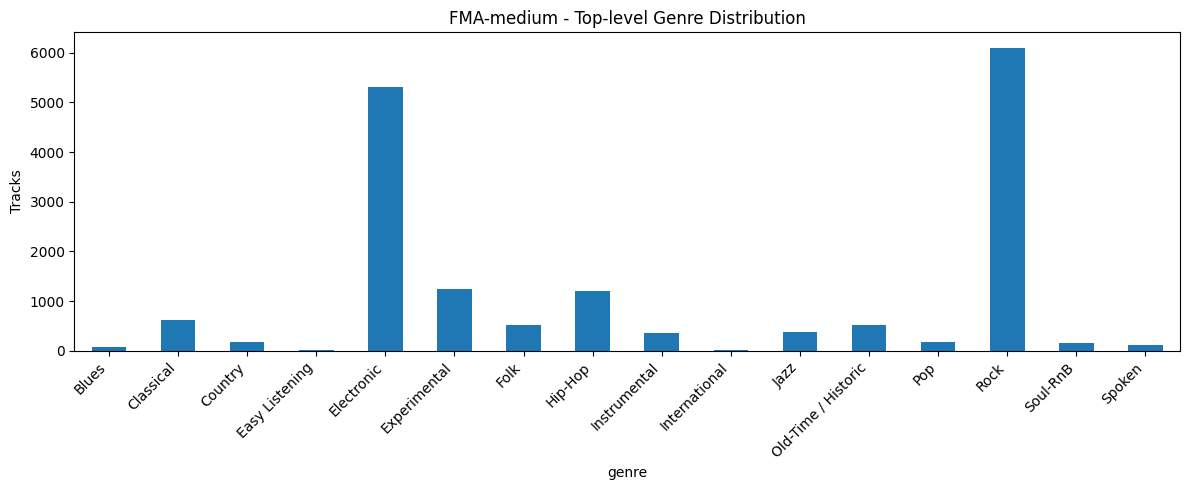

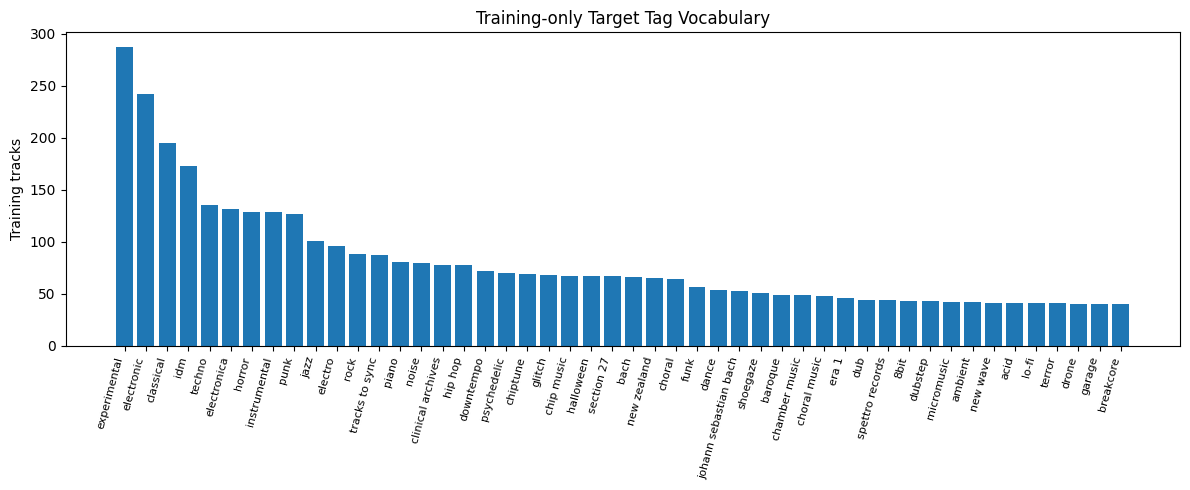

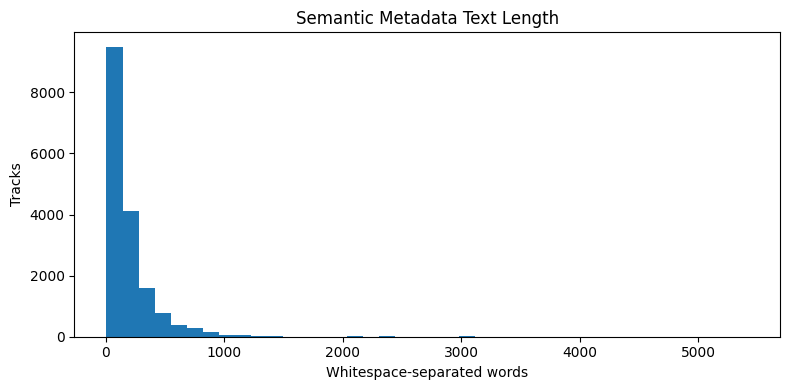

count    17000.000000
mean       191.367059
std        242.761556
min          8.000000
25%         57.000000
50%        126.000000
75%        229.000000
max       5420.000000
Name: text, dtype: float64


In [12]:
# ============================================================
# CELL 12 - DATA EDA
# ============================================================
plt.figure(figsize=(12, 5))
meta["genre"].value_counts().reindex(genre_names).plot(kind="bar")
plt.title("FMA-medium - Top-level Genre Distribution")
plt.ylabel("Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eda_genre_distribution.png", dpi=180)
plt.show()

top_tag_df = pd.DataFrame(
    [(t, train_tag_counter[t]) for t in TAG_VOCAB],
    columns=["tag", "training_count"]
)
plt.figure(figsize=(12, 5))
plt.bar(top_tag_df["tag"], top_tag_df["training_count"])
plt.title("Training-only Target Tag Vocabulary")
plt.ylabel("Training tracks")
plt.xticks(rotation=75, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "eda_target_tag_frequency.png", dpi=180)
plt.show()

text_word_lengths = meta["text"].map(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
plt.hist(text_word_lengths, bins=40)
plt.title("Semantic Metadata Text Length")
plt.xlabel("Whitespace-separated words")
plt.ylabel("Tracks")
plt.tight_layout()
plt.savefig(PLOT_DIR / "eda_text_length.png", dpi=180)
plt.show()

print(text_word_lengths.describe())

# Select the full experiment or development experiment

Use the full experiment for reportable results.

The development option is only for checking that the pipeline runs.

In [13]:
# ============================================================
# CELL 13 - EXPERIMENT SUBSET
# ============================================================
if FAST_DEV_RUN:
    pieces = []
    for split, n in [
        ("training", DEV_TRAIN),
        ("validation", DEV_VAL),
        ("test", DEV_TEST),
    ]:
        part = meta[meta["split"] == split]
        pieces.append(part.sample(n=min(n, len(part)), random_state=SEED))
    exp_meta = pd.concat(pieces).reset_index(drop=True)
else:
    exp_meta = meta.copy().reset_index(drop=True)

print("Experiment tracks:", len(exp_meta))
display(exp_meta["split"].value_counts())

Experiment tracks: 17000


split
training      13522
test           1773
validation     1705
Name: count, dtype: int64

# Robust audio decoding

Audio is loaded at 22,050 samples per second.

FFmpeg is used only when the normal audio decoder fails.

In [14]:
# ============================================================
# CELL 14 - ROBUST AUDIO LOADER
# ============================================================
AUDIO_AUDIT = []

def safe_load_audio(path, track_id=None, sr=SR, duration=DURATION):
    target = int(sr * duration)
    backend = "librosa"

    try:
        y, _ = librosa.load(path, sr=sr, mono=True, duration=duration)
    except Exception:
        backend = "ffmpeg_fallback"
        tmp = Path(tempfile.gettempdir()) / f"fma_task3_{track_id or 'tmp'}.wav"
        try:
            cmd = [
                "ffmpeg", "-v", "error", "-y", "-i", str(path),
                "-ac", "1", "-ar", str(sr), str(tmp)
            ]
            subprocess.run(
                cmd, check=True,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE
            )
            y, native_sr = sf.read(tmp, always_2d=False)
            y = np.asarray(y)
            if y.ndim > 1:
                y = y.mean(axis=1)
            if native_sr != sr:
                y = librosa.resample(
                    y.astype(np.float32),
                    orig_sr=native_sr,
                    target_sr=sr
                )
        finally:
            try:
                tmp.unlink(missing_ok=True)
            except Exception:
                pass

    y = np.asarray(y, dtype=np.float32)

    if len(y) == 0 or not np.isfinite(y).all():
        raise ValueError("Decoded waveform is empty or non-finite.")

    original_len = len(y)

    if len(y) < target:
        if len(y) < int(0.80 * target):
            raise ValueError(f"Decode too short: {len(y)/sr:.2f}s")
        y = np.pad(y, (0, target - len(y)))
    else:
        y = y[:target]

    peak = float(np.max(np.abs(y)))
    rms = float(np.sqrt(np.mean(y**2) + 1e-12))
    if peak < 1e-5 or rms < 1e-6:
        raise ValueError("Near-silent audio.")

    AUDIO_AUDIT.append({
        "track_id": int(track_id) if track_id is not None else -1,
        "backend": backend,
        "seconds_before_padding": original_len / sr,
        "peak": peak,
        "rms": rms,
    })

    return y

# Build audio structure graphs

Each track is divided into groups of four beats.

Fixed three second segments are used only when beat segmentation is unsuitable.

Each graph node contains 100 audio features from MFCC, chroma, spectral contrast, tonnetz, and spectral statistics.

Edges contain temporal adjacency and non local cosine similarity connections.

In [15]:
# ============================================================
# CELL 15 - FRAME DESCRIPTORS
# ============================================================
def compute_frame_descriptors(y):
    stft = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
    power = stft ** 2

    mel = librosa.feature.melspectrogram(
        S=power, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=64
    )
    logmel = librosa.power_to_db(mel, ref=1.0)

    mfcc = librosa.feature.mfcc(S=logmel, n_mfcc=N_MFCC)
    chroma = librosa.feature.chroma_stft(S=power, sr=SR, n_chroma=12)
    contrast = librosa.feature.spectral_contrast(S=stft, sr=SR, n_bands=6)
    tonnetz = librosa.feature.tonnetz(chroma=chroma, sr=SR)

    centroid = librosa.feature.spectral_centroid(S=stft, sr=SR)
    bandwidth = librosa.feature.spectral_bandwidth(S=stft, sr=SR)
    rolloff = librosa.feature.spectral_rolloff(S=stft, sr=SR)
    zcr = librosa.feature.zero_crossing_rate(
        y, frame_length=N_FFT, hop_length=HOP
    )
    rms = librosa.feature.rms(
        S=stft, frame_length=N_FFT, hop_length=HOP
    )

    arrays = [
        mfcc, chroma, contrast, tonnetz,
        centroid, bandwidth, rolloff, zcr, rms
    ]
    T = min(a.shape[1] for a in arrays)
    arrays = [a[:, :T] for a in arrays]
    full = np.vstack(arrays).astype(np.float32)

    # Structural similarity descriptor.
    sim = np.vstack([
        mfcc[:13, :T],
        chroma[:, :T],
        contrast[:, :T],
    ]).astype(np.float32)

    assert full.shape[0] == 50
    assert sim.shape[0] == 32

    return full, sim

In [16]:
# ============================================================
# CELL 16 - BEAT/BAR SEGMENTATION
# ============================================================
def fixed_boundaries():
    vals = list(np.arange(0, DURATION, FALLBACK_SEGMENT_SEC)) + [DURATION]
    return np.asarray(sorted(set(map(float, vals))), dtype=np.float32), "fixed_3s"

def musical_boundaries(y):
    try:
        _, beat_frames = librosa.beat.beat_track(
            y=y, sr=SR, hop_length=HOP
        )
        beat_frames = np.asarray(beat_frames).reshape(-1)

        if len(beat_frames) < 8:
            return fixed_boundaries()

        beat_times = librosa.frames_to_time(
            beat_frames, sr=SR, hop_length=HOP
        )

        raw = [0.0] + list(beat_times[::BEATS_PER_NODE]) + [DURATION]
        raw = np.asarray(
            sorted(set(float(np.clip(x, 0, DURATION)) for x in raw)),
            dtype=np.float32
        )

        kept = [float(raw[0])]
        for x in raw[1:-1]:
            if float(x) - kept[-1] >= MIN_SEGMENT_SEC:
                kept.append(float(x))

        if DURATION - kept[-1] < MIN_SEGMENT_SEC and len(kept) > 1:
            kept[-1] = DURATION
        else:
            kept.append(DURATION)

        boundaries = np.asarray(sorted(set(kept)), dtype=np.float32)
        n_nodes = len(boundaries) - 1

        if n_nodes < MIN_NODES or n_nodes > MAX_NODES:
            return fixed_boundaries()

        return boundaries, "beat_bar"

    except Exception:
        return fixed_boundaries()

In [17]:
# ============================================================
# CELL 17 - AGGREGATE AUDIO INTO GRAPH NODES
# ============================================================
def l2_normalize(v):
    return v / (np.linalg.norm(v) + 1e-8)

def audio_to_nodes(y):
    full, sim = compute_frame_descriptors(y)
    boundaries, seg_mode = musical_boundaries(y)

    node_features = []
    similarity_features = []

    for start_sec, end_sec in zip(boundaries[:-1], boundaries[1:]):
        a = int(librosa.time_to_frames(start_sec, sr=SR, hop_length=HOP))
        b = int(librosa.time_to_frames(end_sec, sr=SR, hop_length=HOP))

        a = max(0, min(a, full.shape[1] - 1))
        b = max(a + 1, min(b, full.shape[1]))

        f = full[:, a:b]
        node = np.concatenate([
            f.mean(axis=1),
            f.std(axis=1),
        ]).astype(np.float32)

        s = sim[:, a:b].mean(axis=1)

        # Prevent one descriptor block from dominating cosine similarity.
        mfcc_s = l2_normalize(s[:13])
        chroma_s = l2_normalize(s[13:25])
        contrast_s = l2_normalize(s[25:32])

        struct = l2_normalize(
            np.concatenate([mfcc_s, chroma_s, contrast_s])
        ).astype(np.float32)

        node_features.append(node)
        similarity_features.append(struct)

    X = np.stack(node_features).astype(np.float32)
    S = np.stack(similarity_features).astype(np.float32)

    assert X.shape[1] == 100
    return X, S, boundaries, seg_mode

In [18]:
# ============================================================
# CELL 18 - TEMPORAL + SIMILARITY EDGES
# ============================================================
def build_graph_edges(S):
    n = len(S)
    edges = {}

    # edge type: 0 temporal, 1 similarity
    for i in range(n - 1):
        edges[(i, i + 1)] = (0, 1.0)
        edges[(i + 1, i)] = (0, 1.0)

    cosine = S @ S.T
    np.fill_diagonal(cosine, -np.inf)

    for i in range(n):
        order = np.argsort(cosine[i])[::-1]
        added = 0

        for j in order:
            j = int(j)

            if abs(i - j) <= 1:
                continue

            score = float(cosine[i, j])

            if score < SIM_THRESHOLD:
                break

            if (i, j) not in edges:
                edges[(i, j)] = (1, score)
            if (j, i) not in edges:
                edges[(j, i)] = (1, score)

            added += 1
            if added >= SIM_TOP_K:
                break

    pairs = sorted(edges)
    edge_index = torch.tensor(pairs, dtype=torch.long).t().contiguous()
    edge_type = torch.tensor(
        [edges[p][0] for p in pairs], dtype=torch.long
    )
    edge_weight = torch.tensor(
        [edges[p][1] for p in pairs], dtype=torch.float32
    )

    return edge_index, edge_type, edge_weight, cosine

In [19]:
# ============================================================
# CELL 19 - TRACK -> RAW GRAPH
# ============================================================
def track_to_raw_graph(row):
    y = safe_load_audio(
        row["audio_path"],
        track_id=int(row["track_id"])
    )

    X, S, boundaries, seg_mode = audio_to_nodes(y)
    edge_index, edge_type, edge_weight, cosine = build_graph_edges(S)

    graph = Data(
        x=torch.tensor(X, dtype=torch.float32),
        edge_index=edge_index,
        edge_type=edge_type,
        edge_weight=edge_weight,
        y=torch.tensor([int(row["genre_label"])], dtype=torch.long),
        track_id=torch.tensor([int(row["track_id"])], dtype=torch.long),
    )

    graph.boundaries = torch.tensor(boundaries, dtype=torch.float32)
    graph.segmentation_mode = seg_mode

    return graph, cosine

Data(x=[11, 100], edge_index=[2, 62], y=[1], edge_type=[62], edge_weight=[62], track_id=[1], boundaries=[12], segmentation_mode='beat_bar')
genre: Hip-Hop
nodes: 11
node dim: 100
temporal directed edges: 20
similarity directed edges: 42
segmentation: beat_bar


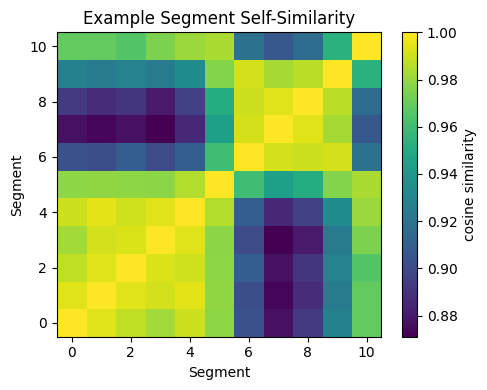

In [20]:
# ============================================================
# CELL 20 - GRAPH SMOKE TEST
# ============================================================
smoke_row = exp_meta.iloc[0]
smoke_graph, smoke_sim = track_to_raw_graph(smoke_row)

print(smoke_graph)
print("genre:", smoke_row["genre"])
print("nodes:", smoke_graph.num_nodes)
print("node dim:", smoke_graph.num_node_features)
print("temporal directed edges:", int((smoke_graph.edge_type == 0).sum()))
print("similarity directed edges:", int((smoke_graph.edge_type == 1).sum()))
print("segmentation:", smoke_graph.segmentation_mode)

plt.figure(figsize=(5, 4))
ssm = smoke_sim.copy()
np.fill_diagonal(ssm, 1.0)
plt.imshow(ssm, origin="lower", aspect="auto")
plt.colorbar(label="cosine similarity")
plt.title("Example Segment Self-Similarity")
plt.xlabel("Segment")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(PLOT_DIR / "example_self_similarity.png", dpi=180)
plt.show()

In [21]:
# ============================================================
# CELL 21 - PRECOMPUTE / RESUME RAW GRAPHS
# ============================================================
graph_failures = []
start = time.time()

for k, row in exp_meta.iterrows():
    tid = int(row["track_id"])
    out = GRAPH_DIR / f"{tid:06d}.pt"

    if out.exists():
        continue

    try:
        graph, _ = track_to_raw_graph(row)
        torch.save(graph, out)
    except Exception as e:
        graph_failures.append({
            "track_id": tid,
            "error": repr(e),
        })

    if (k + 1) % 250 == 0:
        print(
            f"{k+1}/{len(exp_meta)} | "
            f"cached={len(list(GRAPH_DIR.glob('*.pt')))} | "
            f"failures={len(graph_failures)} | "
            f"elapsed={(time.time()-start)/60:.1f} min"
        )

failure_df = pd.DataFrame(
    graph_failures,
    columns=["track_id", "error"]
)
failure_df.to_csv(
    RESULT_DIR / "graph_build_failures.csv",
    index=False
)

print("Cached graphs:", len(list(GRAPH_DIR.glob("*.pt"))))
print("Hard failures:", len(failure_df))
if len(failure_df):
    display(failure_df.head(20))

[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


250/17000 | cached=249 | failures=1 | elapsed=1.6 min
500/17000 | cached=499 | failures=1 | elapsed=3.2 min


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


750/17000 | cached=748 | failures=2 | elapsed=4.8 min
1000/17000 | cached=998 | failures=2 | elapsed=6.4 min
1250/17000 | cached=1248 | failures=2 | elapsed=8.0 min
1500/17000 | cached=1498 | failures=2 | elapsed=9.6 min
1750/17000 | cached=1748 | failures=2 | elapsed=11.2 min
2000/17000 | cached=1998 | failures=2 | elapsed=12.8 min


[src/libmpg123/layer3.c:INT123_do_layer3():1774] error: part2_3_length (3264) too large for available bit count (3224)


...

[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


14500/17000 | cached=14485 | failures=15 | elapsed=92.1 min
14750/17000 | cached=14735 | failures=15 | elapsed=93.7 min
15000/17000 | cached=14985 | failures=15 | elapsed=95.3 min
15250/17000 | cached=15235 | failures=15 | elapsed=96.9 min
15500/17000 | cached=15485 | failures=15 | elapsed=98.5 min
15750/17000 | cached=15735 | failures=15 | elapsed=100.1 min
16000/17000 | cached=15985 | failures=15 | elapsed=101.7 min


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


16250/17000 | cached=16234 | failures=16 | elapsed=103.3 min
16500/17000 | cached=16484 | failures=16 | elapsed=104.9 min
16750/17000 | cached=16734 | failures=16 | elapsed=106.5 min
17000/17000 | cached=16984 | failures=16 | elapsed=108.1 min
Cached graphs: 16984
Hard failures: 16


,track_id,error
0,1486,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
1,5574,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
2,44374,ValueError('Near-silent audio.')
3,48949,ValueError('Near-silent audio.')
4,65753,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
5,80391,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
6,98558,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
7,98559,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
8,98560,"CalledProcessError(1, ['ffmpeg', '-v', 'error'..."
9,98566,ValueError('Decode too short: 6.23s')


In [110]:
# ============================================================
# CELL 22 - GRAPH INTEGRITY + STRUCTURE AUDIT
# ============================================================
audit_rows = []
bad_graphs = []

for p in sorted(GRAPH_DIR.glob("*.pt")):
    try:
        g = torch.load(p, weights_only=False)
        problems = []

        if g.x.ndim != 2 or g.x.shape[1] != 100:
            problems.append(f"x_shape={tuple(g.x.shape)}")

        if not torch.isfinite(g.x).all():
            problems.append("nonfinite_x")

        if g.edge_index.ndim != 2 or g.edge_index.shape[0] != 2:
            problems.append("bad_edge_index")

        if g.edge_index.numel() and int(g.edge_index.max()) >= g.num_nodes:
            problems.append("edge_out_of_range")

        temporal = int((g.edge_type == 0).sum())
        similarity = int((g.edge_type == 1).sum())

        audit_rows.append({
            "track_id": int(g.track_id.item()),
            "nodes": g.num_nodes,
            "edges": g.num_edges,
            "temporal_edges": temporal,
            "similarity_edges": similarity,
            "similarity_edges_per_node": similarity / max(g.num_nodes, 1),
            "segmentation_mode": getattr(g, "segmentation_mode", "unknown"),
        })

        if problems:
            bad_graphs.append({
                "file": p.name,
                "problem": "; ".join(problems),
            })

    except Exception as e:
        bad_graphs.append({
            "file": p.name,
            "problem": repr(e),
        })

audit_df = pd.DataFrame(audit_rows)
bad_df = pd.DataFrame(
    bad_graphs,
    columns=["file", "problem"]
)

audit_df.to_csv(RESULT_DIR / "graph_audit.csv", index=False)
bad_df.to_csv(RESULT_DIR / "bad_graphs.csv", index=False)

numeric_graph_audit = audit_df.select_dtypes(include=[np.number])

if (
    len(numeric_graph_audit.columns) > 0
    and len(numeric_graph_audit) > 0
):
    display(
        numeric_graph_audit.describe()
    )
print("\nSegmentation modes:")
display(audit_df["segmentation_mode"].value_counts())

print("Bad graphs:", len(bad_df))
print(
    "Mean similarity directed edges/node:",
    float(audit_df["similarity_edges_per_node"].mean())
)

if audit_df["similarity_edges_per_node"].mean() < 1.0:
    print(
        "\nWARNING: non-local graph is sparse. "
        "Consider SIM_THRESHOLD=0.40 and rebuild this Task-3 graph cache."
    )
else:
    print("\nPASS: non-local similarity structure is materially present.")

,track_id,nodes,edges,temporal_edges,similarity_edges,similarity_edges_per_node
count,16984.000000,16984.000000,16984.000000,16984.000000,16984.000000,16984.000000
mean,74328.766722,14.560469,86.735516,27.120937,59.614578,4.079467
std,44701.523903,3.517069,22.626215,7.034138,15.795894,0.311647
min,3.000000,6.000000,28.000000,10.000000,18.000000,3.000000
25%,34998.750000,12.000000,70.000000,22.000000,48.000000,3.866667
50%,70457.500000,14.000000,86.000000,26.000000,58.000000,4.100000
75%,115258.500000,17.000000,102.000000,32.000000,70.000000,4.300000
max,155314.000000,24.000000,162.000000,46.000000,118.000000,5.142857



Segmentation modes:


segmentation_mode
beat_bar    16741
fixed_3s      243
Name: count, dtype: int64

Bad graphs: 0
Mean similarity directed edges/node: 4.079467414411428

PASS: non-local similarity structure is materially present.


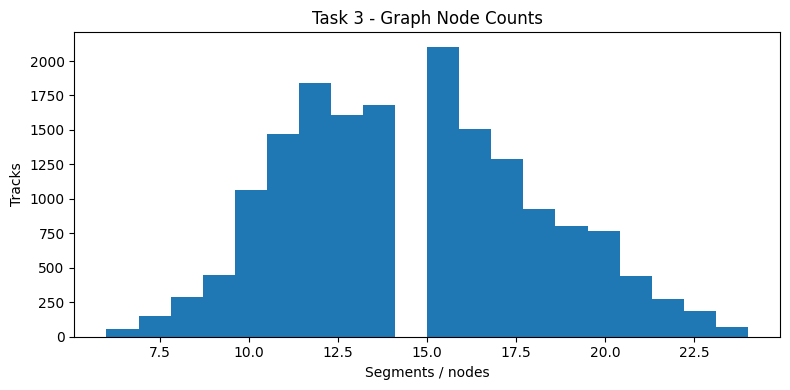

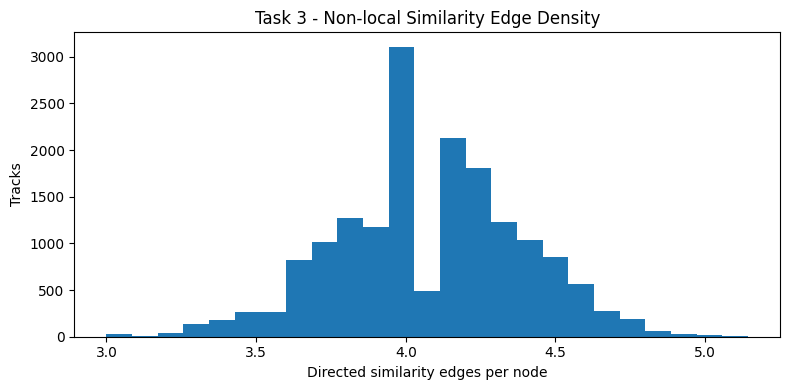

In [111]:
# ============================================================
# CELL 23 - GRAPH AUDIT FIGURES
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(audit_df["nodes"], bins=20)
plt.title("Task 3 - Graph Node Counts")
plt.xlabel("Segments / nodes")
plt.ylabel("Tracks")
plt.tight_layout()
plt.savefig(PLOT_DIR / "graph_node_distribution.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(audit_df["similarity_edges_per_node"], bins=25)
plt.title("Task 3 - Non-local Similarity Edge Density")
plt.xlabel("Directed similarity edges per node")
plt.ylabel("Tracks")
plt.tight_layout()
plt.savefig(PLOT_DIR / "graph_similarity_density.png", dpi=180)
plt.show()

# Keep only valid paired tracks

All four models use the same valid tracks so the comparison is fair.

In [112]:
# ============================================================
# CELL 24 - VALID PAIRED METADATA
# ============================================================
bad_names = set(bad_df["file"]) if len(bad_df) else set()

valid_ids = {
    int(p.stem)
    for p in GRAPH_DIR.glob("*.pt")
    if p.name not in bad_names
}

paired_meta = exp_meta[
    exp_meta["track_id"].isin(valid_ids)
].copy().reset_index(drop=True)

train_meta = paired_meta[paired_meta["split"] == "training"].copy().reset_index(drop=True)
val_meta = paired_meta[paired_meta["split"] == "validation"].copy().reset_index(drop=True)
test_meta = paired_meta[paired_meta["split"] == "test"].copy().reset_index(drop=True)

print("Paired train:", len(train_meta))
print("Paired val  :", len(val_meta))
print("Paired test :", len(test_meta))

Paired train: 13509
Paired val  : 1704
Paired test : 1771


# Normalize graph features

The graph node StandardScaler is fitted using training nodes only.

The fitted scaler is then reused for validation and test graphs.

In [113]:
# ============================================================
# CELL 25 - FIT GRAPH NODE SCALER
# ============================================================
node_scaler = StandardScaler()

for k, tid in enumerate(train_meta["track_id"].astype(int)):
    g = torch.load(
        GRAPH_DIR / f"{tid:06d}.pt",
        weights_only=False
    )
    node_scaler.partial_fit(g.x.numpy())

    if (k + 1) % 2000 == 0:
        print("Scaler:", k + 1, "/", len(train_meta))

joblib.dump(
    node_scaler,
    PREPROCESSING_DIR / "graph_node_scaler.joblib"
)

print("Scaler feature dimension:", len(node_scaler.mean_))

Scaler: 2000 / 13509
Scaler: 4000 / 13509
Scaler: 6000 / 13509
Scaler: 8000 / 13509
Scaler: 10000 / 13509
Scaler: 12000 / 13509
Scaler feature dimension: 100


# Tokenize semantic text

DistilBERT tokenization is performed once before training.

The maximum text length is 128 tokens.

In [114]:
# ============================================================
# CELL 26 - LOAD TOKENIZER
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

tokenized = tokenizer(
    paired_meta["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_TEXT_LENGTH,
    return_tensors="np",
)

TOKEN_INPUT_IDS = tokenized["input_ids"].astype(np.int64)
TOKEN_MASKS = tokenized["attention_mask"].astype(np.int64)

paired_meta["token_index"] = np.arange(len(paired_meta))

# Re-create split frames so token_index is preserved.
train_meta = paired_meta[paired_meta["split"] == "training"].copy().reset_index(drop=True)
val_meta = paired_meta[paired_meta["split"] == "validation"].copy().reset_index(drop=True)
test_meta = paired_meta[paired_meta["split"] == "test"].copy().reset_index(drop=True)

print("Token IDs:", TOKEN_INPUT_IDS.shape)
print("Masks    :", TOKEN_MASKS.shape)

Token IDs: (16984, 128)
Masks    : (16984, 128)


In [115]:
# ============================================================
# CELL 27 - TAG CLASS WEIGHTS FROM TRAINING ONLY
# ============================================================
train_tag_matrix = np.stack([
    TAG_TARGETS[int(tid)]
    for tid in train_meta["track_id"]
])

positive = train_tag_matrix.sum(axis=0)
negative = len(train_tag_matrix) - positive

pos_weight_np = negative / np.maximum(positive, 1)
pos_weight_np = np.clip(pos_weight_np, 1.0, MAX_POS_WEIGHT)
TAG_POS_WEIGHT = torch.tensor(
    pos_weight_np,
    dtype=torch.float32,
    device=DEVICE
)

tag_weight_table = pd.DataFrame({
    "tag": TAG_VOCAB,
    "train_positive": positive.astype(int),
    "pos_weight": pos_weight_np,
})
display(tag_weight_table)
tag_weight_table.to_csv(
    RESULT_DIR / "tag_class_weights.csv",
    index=False
)

,tag,train_positive,pos_weight
0,experimental,287,12.0
1,electronic,242,12.0
2,classical,195,12.0
3,idm,173,12.0
4,techno,135,12.0
5,electronica,132,12.0
6,horror,129,12.0
7,instrumental,129,12.0
8,punk,127,12.0
9,jazz,101,12.0


In [116]:
# ============================================================
# CELL 28 - SAVE OFFICIAL/PAIRED SPLITS
# ============================================================
for split_name, frame in [
    ("training", train_meta),
    ("validation", val_meta),
    ("test", test_meta),
]:
    with open(SPLIT_DIR / f"{split_name}.json", "w") as f:
        json.dump(
            frame[
                ["track_id", "genre", "genre_label", "artist_id"]
            ].to_dict("records"),
            f,
            indent=2,
        )

with open(CONFIG_DIR / "tag_vocabulary.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "tag_to_index": tag2idx,
            "min_training_count": MIN_TAG_TRAIN_COUNT,
        },
        f,
        indent=2,
    )

print("Saved splits and frozen tag vocabulary.")

with open(
    CONFIG_DIR
    / "genre_mapping.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        {
            "genre_to_index": genre2idx,
            "index_to_genre": {
                str(key): value
                for key, value
                in idx2genre.items()
            },
        },
        file,
        indent=2,
    )


Saved splits and frozen tag vocabulary.


# Multimodal PyTorch Geometric dataset

Each item contains a scaled audio graph, genre target, multi label tag target, BERT token identifiers, attention mask, and track identifier.

In [117]:
# ============================================================
# CELL 29 - MULTIMODAL DATASET
# ============================================================
class FMAMultimodalDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        frame,
        graph_dir,
        node_scaler,
        token_ids,
        token_masks,
    ):
        self.frame = frame.reset_index(drop=True)
        self.graph_dir = Path(graph_dir)

        self.node_mean = torch.tensor(
            node_scaler.mean_,
            dtype=torch.float32
        )
        self.node_scale = torch.tensor(
            node_scaler.scale_ + 1e-8,
            dtype=torch.float32
        )

        self.token_ids = token_ids
        self.token_masks = token_masks

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        tid = int(row["track_id"])

        g = torch.load(
            self.graph_dir / f"{tid:06d}.pt",
            weights_only=False
        )

        g.x = (g.x - self.node_mean) / self.node_scale
        g.x = torch.clamp(g.x, -6.0, 6.0)

        tok_idx = int(row["token_index"])

        # Shape [1,L], so PyG concatenates to [B,L].
        g.input_ids = torch.tensor(
            self.token_ids[tok_idx],
            dtype=torch.long
        ).unsqueeze(0)

        g.attention_mask = torch.tensor(
            self.token_masks[tok_idx],
            dtype=torch.long
        ).unsqueeze(0)

        g.tag_y = torch.tensor(
            TAG_TARGETS[tid],
            dtype=torch.float32
        ).unsqueeze(0)

        return g

train_ds = FMAMultimodalDataset(
    train_meta, GRAPH_DIR, node_scaler,
    TOKEN_INPUT_IDS, TOKEN_MASKS
)
val_ds = FMAMultimodalDataset(
    val_meta, GRAPH_DIR, node_scaler,
    TOKEN_INPUT_IDS, TOKEN_MASKS
)
test_ds = FMAMultimodalDataset(
    test_meta, GRAPH_DIR, node_scaler,
    TOKEN_INPUT_IDS, TOKEN_MASKS
)

train_loader = GeoDataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = GeoDataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = GeoDataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

batch0 = next(iter(train_loader))

print("Graphs:", batch0.num_graphs)
print("node x:", batch0.x.shape)
print("genre y:", batch0.y.shape)
print("tag y:", batch0.tag_y.shape)
print("input_ids:", batch0.input_ids.shape)
print("attention_mask:", batch0.attention_mask.shape)

Graphs: 12
node x: torch.Size([186, 100])
genre y: torch.Size([12])
tag y: torch.Size([12, 48])
input_ids: torch.Size([12, 128])
attention_mask: torch.Size([12, 128])


# GraphSAGE structural encoder

Two residual GraphSAGE layers perform message passing over temporal and similarity edges.

Global mean pooling produces one graph representation for each track.

In [118]:
# ============================================================
# CELL 30 - GRAPHSAGE ENCODER
# ============================================================
class GraphEncoder(nn.Module):
    def __init__(
        self,
        in_dim=100,
        hidden=GNN_HIDDEN,
        dropout=DROPOUT,
    ):
        super().__init__()
        self.dropout = dropout

        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
        )

        self.conv1 = SAGEConv(
            hidden, hidden,
            aggr="mean"
        )
        self.conv2 = SAGEConv(
            hidden, hidden,
            aggr="mean"
        )

        self.norm1 = nn.LayerNorm(hidden)
        self.norm2 = nn.LayerNorm(hidden)

    def forward_nodes(self, batch):
        h = self.input_proj(batch.x)

        z = self.conv1(
            h,
            batch.edge_index
        )
        h = self.norm1(
            h + F.dropout(
                F.gelu(z),
                p=self.dropout,
                training=self.training
            )
        )

        z = self.conv2(
            h,
            batch.edge_index
        )
        h = self.norm2(
            h + F.dropout(
                F.gelu(z),
                p=self.dropout,
                training=self.training
            )
        )

        return h

    def forward(self, batch):
        h = self.forward_nodes(batch)

        g = global_mean_pool(
            h,
            batch.batch
        )

        return g

# DistilBERT text encoder

DistilBERT is used as the semantic text encoder.

Most BERT parameters are frozen and the final two transformer blocks are fine tuned.

In [119]:
# ============================================================
# CELL 31 - TEXT ENCODER
# ============================================================
class TextEncoder(nn.Module):
    def __init__(self, model_name=TEXT_MODEL_NAME, unfreeze_last_n=2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = int(self.bert.config.hidden_size)

        # Freeze everything.
        for p in self.bert.parameters():
            p.requires_grad = False

        # DistilBERT.
        if hasattr(self.bert, "transformer"):
            layers = self.bert.transformer.layer

        # BERT/RoBERTa style.
        elif hasattr(self.bert, "encoder"):
            layers = self.bert.encoder.layer

        else:
            layers = []

        if unfreeze_last_n > 0 and len(layers) > 0:
            for layer in layers[-unfreeze_last_n:]:
                for p in layer.parameters():
                    p.requires_grad = True

        # Unfreeze final norm if model has one.
        if hasattr(self.bert, "transformer") and hasattr(self.bert.transformer, "layer"):
            pass

    def forward(self, input_ids, attention_mask):
        out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )

        H = out.last_hidden_state
        cls = H[:, 0, :]

        return H, cls

# Shared prediction heads

Every model predicts the same genre and multi label tag targets.

In [120]:
# ============================================================
# CELL 32 - MULTI-TASK HEAD
# ============================================================
class ContextHeads(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(in_dim, FUSION_DIM),
            nn.LayerNorm(FUSION_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )

        self.genre_head = nn.Linear(
            FUSION_DIM,
            NUM_GENRES
        )

        self.tag_head = nn.Linear(
            FUSION_DIM,
            NUM_TAGS
        )

    def forward(self, z):
        h = self.shared(z)

        return (
            self.genre_head(h),
            self.tag_head(h),
            h,
        )

# BERT only ablation

In [121]:
# ============================================================
# CELL 33 - BERT-ONLY MODEL
# ============================================================
class BERTOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.text_encoder = TextEncoder()
        text_dim = self.text_encoder.hidden_size

        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, FUSION_DIM),
            nn.LayerNorm(FUSION_DIM),
            nn.GELU(),
        )

        self.heads = ContextHeads(FUSION_DIM)

    def forward(self, batch, return_aux=False):
        H, cls = self.text_encoder(
            batch.input_ids,
            batch.attention_mask
        )

        z0 = self.text_proj(cls)

        genre_logits, tag_logits, z = self.heads(z0)

        out = {
            "genre_logits": genre_logits,
            "tag_logits": tag_logits,
            "embedding": z,
        }

        if return_aux:
            out["text_hidden"] = H

        return out

# GNN only ablation

In [122]:
# ============================================================
# CELL 34 - GNN-ONLY MODEL
# ============================================================
class GNNOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.graph_encoder = GraphEncoder()

        self.graph_proj = nn.Sequential(
            nn.Linear(GNN_HIDDEN, FUSION_DIM),
            nn.LayerNorm(FUSION_DIM),
            nn.GELU(),
        )

        self.heads = ContextHeads(FUSION_DIM)

    def forward(self, batch, return_aux=False):
        g = self.graph_encoder(batch)
        z0 = self.graph_proj(g)

        genre_logits, tag_logits, z = self.heads(z0)

        return {
            "genre_logits": genre_logits,
            "tag_logits": tag_logits,
            "embedding": z,
            "graph_embedding": g,
        }

# Early concatenation ablation

The projected graph representation and projected BERT representation are concatenated before prediction.

In [123]:
# ============================================================
# CELL 35 - EARLY CONCAT MODEL
# ============================================================
class EarlyConcatModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.graph_encoder = GraphEncoder()
        self.text_encoder = TextEncoder()

        self.graph_proj = nn.Sequential(
            nn.Linear(GNN_HIDDEN, FUSION_DIM),
            nn.LayerNorm(FUSION_DIM),
            nn.GELU(),
        )

        self.text_proj = nn.Sequential(
            nn.Linear(
                self.text_encoder.hidden_size,
                FUSION_DIM
            ),
            nn.LayerNorm(FUSION_DIM),
            nn.GELU(),
        )

        self.heads = ContextHeads(
            2 * FUSION_DIM
        )

    def forward(self, batch, return_aux=False):
        g = self.graph_encoder(batch)

        H, cls = self.text_encoder(
            batch.input_ids,
            batch.attention_mask
        )

        z0 = torch.cat([
            self.graph_proj(g),
            self.text_proj(cls),
        ], dim=1)

        genre_logits, tag_logits, z = self.heads(z0)

        out = {
            "genre_logits": genre_logits,
            "tag_logits": tag_logits,
            "embedding": z,
            "graph_embedding": g,
        }

        if return_aux:
            out["text_hidden"] = H

        return out

# Cross attention fusion

The graph representation acts as a query over BERT token representations.

The attended text context is concatenated with the graph representation before genre and tag prediction.

In [124]:
# ============================================================
# CELL 36 - CROSS-ATTENTION MODEL
# ============================================================
class CrossAttentionFusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.graph_encoder = GraphEncoder()
        self.text_encoder = TextEncoder()

        text_dim = self.text_encoder.hidden_size

        self.q_proj = nn.Linear(
            GNN_HIDDEN,
            ATTENTION_DIM
        )

        self.k_proj = nn.Linear(
            text_dim,
            ATTENTION_DIM
        )

        self.v_proj = nn.Linear(
            text_dim,
            ATTENTION_DIM
        )

        self.graph_fusion_proj = nn.Sequential(
            nn.Linear(
                GNN_HIDDEN,
                ATTENTION_DIM
            ),
            nn.LayerNorm(ATTENTION_DIM),
            nn.GELU(),
        )

        self.context_norm = nn.LayerNorm(
            ATTENTION_DIM
        )

        self.heads = ContextHeads(
            2 * ATTENTION_DIM
        )

    def forward(self, batch, return_aux=False):
        g = self.graph_encoder(batch)

        H, cls = self.text_encoder(
            batch.input_ids,
            batch.attention_mask
        )

        q = self.q_proj(g).unsqueeze(1)
        K = self.k_proj(H)
        V = self.v_proj(H)

        scores = torch.matmul(
            q,
            K.transpose(1, 2)
        ).squeeze(1)

        scores = scores / math.sqrt(
            ATTENTION_DIM
        )

        # Ignore padding tokens.
        scores = scores.masked_fill(
            batch.attention_mask == 0,
            torch.finfo(scores.dtype).min
        )

        attention = torch.softmax(
            scores,
            dim=1
        )

        context = torch.bmm(
            attention.unsqueeze(1),
            V
        ).squeeze(1)

        context = self.context_norm(
            context
        )

        z0 = torch.cat([
            self.graph_fusion_proj(g),
            context,
        ], dim=1)

        genre_logits, tag_logits, z = self.heads(z0)

        out = {
            "genre_logits": genre_logits,
            "tag_logits": tag_logits,
            "embedding": z,
            "graph_embedding": g,
        }

        if return_aux:
            out["attention"] = attention
            out["text_hidden"] = H

        return out

In [125]:
# ============================================================
# CELL 37 - MODEL FACTORY
# ============================================================
def build_model(name):
    if name == "bert_only":
        return BERTOnlyModel()

    if name == "gnn_only":
        return GNNOnlyModel()

    if name == "early_concat":
        return EarlyConcatModel()

    if name == "cross_attention":
        return CrossAttentionFusionModel()

    raise ValueError(name)

# Shape smoke test on one model.
smoke_model = build_model("cross_attention").to(DEVICE)
smoke_batch = next(iter(train_loader)).to(DEVICE)

with torch.no_grad():
    smoke_out = smoke_model(
        smoke_batch,
        return_aux=True
    )

print("genre logits:", smoke_out["genre_logits"].shape)
print("tag logits:", smoke_out["tag_logits"].shape)
print("fusion embedding:", smoke_out["embedding"].shape)
print("attention:", smoke_out["attention"].shape)

del smoke_model, smoke_batch, smoke_out
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

genre logits: torch.Size([12, 16])
tag logits: torch.Size([12, 48])
fusion embedding: torch.Size([12, 256])
attention: torch.Size([12, 128])


# Multi task loss

Genre prediction uses cross entropy loss.

Tag prediction uses binary cross entropy with training only positive class weights.

The two losses are added together.

In [126]:
# ============================================================
# CELL 38 - LOSS
# ============================================================
tag_loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=TAG_POS_WEIGHT
)

def multitask_loss(outputs, batch):
    genre_target = batch.y.view(-1)
    tag_target = batch.tag_y

    genre_loss = F.cross_entropy(
        outputs["genre_logits"],
        genre_target,
        label_smoothing=LABEL_SMOOTHING
    )

    tag_loss = tag_loss_fn(
        outputs["tag_logits"],
        tag_target
    )

    total = (
        genre_loss
        + TAG_LOSS_WEIGHT * tag_loss
    )

    return total, genre_loss, tag_loss

# Evaluation metrics

Genre metrics

Accuracy.

Macro F1 score.

Micro F1 score.

Tag metrics

Macro F1 score.

Micro F1 score.

Mean Average Precision across tags, which is the mean per tag Area Under the Precision Recall Curve.

A single tag probability threshold is selected using validation data only.

In [127]:
# ============================================================
# CELL 39 - TAG THRESHOLD / METRICS
# ============================================================
def tune_global_tag_threshold(
    y_true,
    probs
):
    best_threshold = 0.5
    best_macro = -1

    for threshold in np.arange(
        0.10,
        0.66,
        0.05
    ):
        pred = (
            probs >= threshold
        ).astype(int)

        score = f1_score(
            y_true,
            pred,
            average="macro",
            zero_division=0
        )

        if score > best_macro:
            best_macro = score
            best_threshold = float(threshold)

    return best_threshold, best_macro


def compute_all_metrics(
    genre_true,
    genre_pred,
    tag_true,
    tag_probs,
    tag_threshold
):
    tag_pred = (
        tag_probs >= tag_threshold
    ).astype(int)

    per_ap = average_precision_score(
        tag_true,
        tag_probs,
        average=None
    )

    return {
        "genre_accuracy":
            accuracy_score(
                genre_true,
                genre_pred
            ),

        "genre_macro_f1":
            f1_score(
                genre_true,
                genre_pred,
                average="macro"
            ),

        "genre_micro_f1":
            f1_score(
                genre_true,
                genre_pred,
                average="micro"
            ),

        "tag_macro_f1":
            f1_score(
                tag_true,
                tag_pred,
                average="macro",
                zero_division=0
            ),

        "tag_micro_f1":
            f1_score(
                tag_true,
                tag_pred,
                average="micro",
                zero_division=0
            ),

        "tag_mAP":
            float(np.nanmean(per_ap)),
    }

# Optimizer

Fine tuned BERT parameters use a smaller learning rate.

New graph, fusion, and classification layers use a larger learning rate.

In [128]:
# ============================================================
# CELL 40 - OPTIMIZER FACTORY
# ============================================================
def build_optimizer(model):
    bert_params = []
    new_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        if "text_encoder.bert" in name:
            bert_params.append(p)
        else:
            new_params.append(p)

    groups = []

    if bert_params:
        groups.append({
            "params": bert_params,
            "lr": LR_BERT,
            "weight_decay": WEIGHT_DECAY,
        })

    if new_params:
        groups.append({
            "params": new_params,
            "lr": LR_NEW,
            "weight_decay": WEIGHT_DECAY,
        })

    return torch.optim.AdamW(groups)

In [129]:
# ============================================================
# CELL 41 - ONE EPOCH
# ============================================================
def run_epoch(
    model,
    loader,
    optimizer=None,
):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_genre_loss = 0.0
    total_tag_loss = 0.0
    n_samples = 0

    genre_true = []
    genre_pred = []

    tag_true = []
    tag_probs = []

    track_ids = []

    if training:
        optimizer.zero_grad(set_to_none=True)

    scaler_amp = torch.amp.GradScaler(
        "cuda",
        enabled=AMP,
    )

    for step, batch in enumerate(loader):
        batch = batch.to(DEVICE)

        with torch.amp.autocast(
            device_type=DEVICE.type,
            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),
            enabled=AMP,
        ):
            outputs = model(batch)

            loss, genre_loss, tag_loss = (
                multitask_loss(
                    outputs,
                    batch
                )
            )

            loss_for_backward = (
                loss / GRAD_ACCUM_STEPS
            )

        if training:
            scaler_amp.scale(
                loss_for_backward
            ).backward()

            do_step = (
                (step + 1) % GRAD_ACCUM_STEPS == 0
                or
                (step + 1) == len(loader)
            )

            if do_step:
                scaler_amp.unscale_(
                    optimizer
                )

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    2.0
                )

                scaler_amp.step(
                    optimizer
                )

                scaler_amp.update()

                optimizer.zero_grad(
                    set_to_none=True
                )

        b = batch.y.numel()

        total_loss += (
            float(loss.detach().cpu())
            * b
        )

        total_genre_loss += (
            float(
                genre_loss.detach().cpu()
            )
            * b
        )

        total_tag_loss += (
            float(
                tag_loss.detach().cpu()
            )
            * b
        )

        n_samples += b

        gp = torch.softmax(
            outputs["genre_logits"],
            dim=1
        )

        genre_true.extend(
            batch.y.view(-1)
            .detach().cpu().numpy()
        )

        genre_pred.extend(
            gp.argmax(1)
            .detach().cpu().numpy()
        )

        tag_true.extend(
            batch.tag_y
            .detach().cpu().numpy()
        )

        tag_probs.extend(
            torch.sigmoid(
                outputs["tag_logits"]
            )
            .detach().cpu().numpy()
        )

        track_ids.extend(
            batch.track_id.view(-1)
            .detach().cpu().numpy()
        )

    return {
        "loss":
            total_loss / max(n_samples, 1),

        "genre_loss":
            total_genre_loss / max(n_samples, 1),

        "tag_loss":
            total_tag_loss / max(n_samples, 1),

        "genre_true":
            np.asarray(genre_true),

        "genre_pred":
            np.asarray(genre_pred),

        "tag_true":
            np.asarray(tag_true),

        "tag_probs":
            np.asarray(tag_probs),

        "track_ids":
            np.asarray(track_ids),
    }

# Train one model

The best Epoch is selected using the average of validation genre Macro F1 score and validation tag Mean Average Precision.

Best model parameters stay in memory only.

No model weight file is saved.

In [130]:
# CELL 42  Train one model without saving model weights

def train_one_model(
    model_name,
):
    display_name = MODEL_DISPLAY_NAMES[
        model_name
    ]

    print()
    print("=" * 72)
    print("Training:", display_name)
    print("=" * 72)

    model = build_model(
        model_name
    ).to(DEVICE)

    optimizer = build_optimizer(
        model
    )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=1,
        )
    )

    best_score = -np.inf
    best_epoch = -1
    best_validation_threshold = 0.5
    best_state_dict = None
    epochs_without_improvement = 0
    history_rows = []

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        training_raw = run_epoch(
            model,
            train_loader,
            optimizer,
        )

        validation_raw = run_epoch(
            model,
            val_loader,
        )

        validation_threshold, _ = (
            tune_global_tag_threshold(
                validation_raw["tag_true"],
                validation_raw["tag_probs"],
            )
        )

        training_threshold, _ = (
            tune_global_tag_threshold(
                training_raw["tag_true"],
                training_raw["tag_probs"],
            )
        )

        training_metrics = (
            compute_all_metrics(
                training_raw["genre_true"],
                training_raw["genre_pred"],
                training_raw["tag_true"],
                training_raw["tag_probs"],
                training_threshold,
            )
        )

        validation_metrics = (
            compute_all_metrics(
                validation_raw["genre_true"],
                validation_raw["genre_pred"],
                validation_raw["tag_true"],
                validation_raw["tag_probs"],
                validation_threshold,
            )
        )

        validation_composite_score = (
            0.5
            * (
                validation_metrics[
                    "genre_macro_f1"
                ]
                + validation_metrics[
                    "tag_mAP"
                ]
            )
        )

        scheduler.step(
            validation_composite_score
        )

        history_rows.append({
            "epoch": epoch,
            "training_loss": training_raw["loss"],
            "validation_loss": validation_raw["loss"],
            "training_genre_macro_f1_score": training_metrics["genre_macro_f1"],
            "validation_genre_macro_f1_score": validation_metrics["genre_macro_f1"],
            "training_tag_macro_f1_score": training_metrics["tag_macro_f1"],
            "validation_tag_macro_f1_score": validation_metrics["tag_macro_f1"],
            "training_tag_mean_average_precision": training_metrics["tag_mAP"],
            "validation_tag_mean_average_precision": validation_metrics["tag_mAP"],
            "validation_selected_tag_probability_threshold": validation_threshold,
            "validation_composite_score": validation_composite_score,
        })

        print()
        print(
            "Epoch",
            epoch,
            "of",
            MAX_EPOCHS,
        )

        print(
            "Training loss:",
            f"{training_raw['loss']:.4f}",
        )

        print(
            "Validation loss:",
            f"{validation_raw['loss']:.4f}",
        )

        print(
            "Training genre Macro F1 score:",
            f"{training_metrics['genre_macro_f1']:.4f}",
        )

        print(
            "Validation genre Macro F1 score:",
            f"{validation_metrics['genre_macro_f1']:.4f}",
        )

        print(
            "Training tag Macro F1 score:",
            f"{training_metrics['tag_macro_f1']:.4f}",
        )

        print(
            "Validation tag Macro F1 score:",
            f"{validation_metrics['tag_macro_f1']:.4f}",
        )

        print(
            "Validation tag Mean Average Precision:",
            f"{validation_metrics['tag_mAP']:.4f}",
        )

        print(
            "Validation selected tag probability threshold:",
            f"{validation_threshold:.2f}",
        )

        if (
            validation_composite_score
            > best_score + 1e-5
        ):
            best_score = (
                validation_composite_score
            )

            best_epoch = epoch
            best_validation_threshold = (
                validation_threshold
            )

            epochs_without_improvement = 0

            best_state_dict = {
                name: value
                .detach()
                .cpu()
                .clone()
                for name, value
                in model.state_dict().items()
            }

            print(
                "Best model parameters in memory updated."
            )

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= PATIENCE
        ):
            print(
                "Early stopping triggered."
            )
            break

    history = pd.DataFrame(
        history_rows
    )

    history.to_csv(
        METRICS_DIR
        / f"{model_name}_training_history.csv",
        index=False,
    )

    if best_state_dict is None:
        raise RuntimeError(
            f"No best state was recorded for {display_name}."
        )

    model.load_state_dict(
        best_state_dict
    )

    model.eval()

    print()
    print(
        "Best Epoch for",
        display_name,
        ":",
        best_epoch,
    )

    print(
        "Best validation composite score:",
        f"{best_score:.4f}",
    )

    return (
        model,
        history,
        float(
            best_validation_threshold
        ),
        int(best_epoch),
        float(best_score),
    )

# Train the four required ablations

BERT only, GNN only, early concatenation, and cross attention are trained with the same data and targets.

In [131]:
# CELL 43  Train all four ablation models

trained_models = {}
training_histories = {}
tag_thresholds = {}
best_epochs = {}
best_validation_scores = {}

for model_name in MODELS_TO_RUN:
    (
        model,
        history,
        threshold,
        best_epoch,
        best_validation_score,
    ) = train_one_model(
        model_name
    )

    trained_models[
        model_name
    ] = model

    training_histories[
        model_name
    ] = history

    tag_thresholds[
        model_name
    ] = threshold

    best_epochs[
        model_name
    ] = best_epoch

    best_validation_scores[
        model_name
    ] = best_validation_score

    model.to(
        "cpu"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print()
print(
    "Validation selected tag probability thresholds"
)

for model_name in MODELS_TO_RUN:
    print(
        MODEL_DISPLAY_NAMES[
            model_name
        ],
        ":",
        tag_thresholds[
            model_name
        ],
    )


Training: BERT only

Epoch 1 of 12
Training loss: 1.2487
Validation loss: 1.4416
Training genre Macro F1 score: 0.4338
Validation genre Macro F1 score: 0.4761
Training tag Macro F1 score: 0.0817
Validation tag Macro F1 score: 0.1024
Validation tag Mean Average Precision: 0.0950
Validation selected tag probability threshold: 0.50
Best model parameters in memory updated.

Epoch 2 of 12
Training loss: 0.7854
Validation loss: 1.6506
Training genre Macro F1 score: 0.6716
Validation genre Macro F1 score: 0.5168
Training tag Macro F1 score: 0.3121
Validation tag Macro F1 score: 0.1144
Validation tag Mean Average Precision: 0.1767
Validation selected tag probability threshold: 0.45
Best model parameters in memory updated.

Epoch 3 of 12
Training loss: 0.5970
Validation loss: 1.7381
Training genre Macro F1 score: 0.8043
Validation genre Macro F1 score: 0.4016
Training tag Macro F1 score: 0.4841
Validation tag Macro F1 score: 0.1743
Validation tag Mean Average Precision: 0.1885
Validation selec

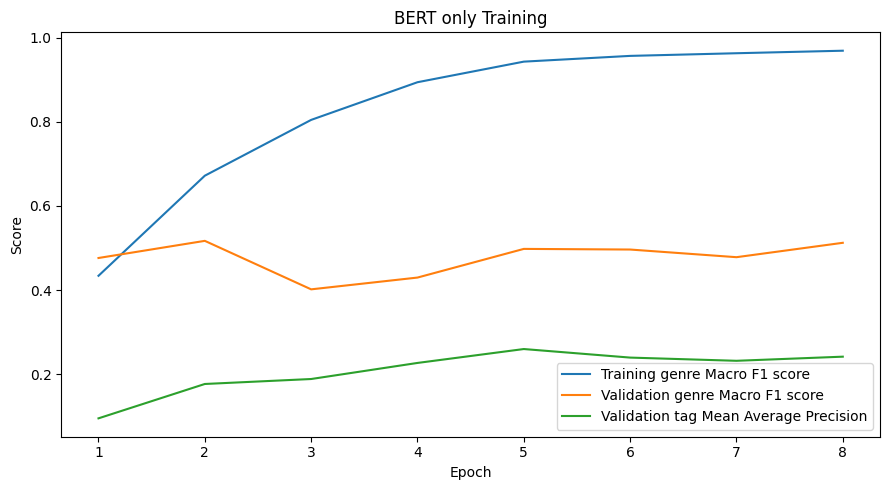

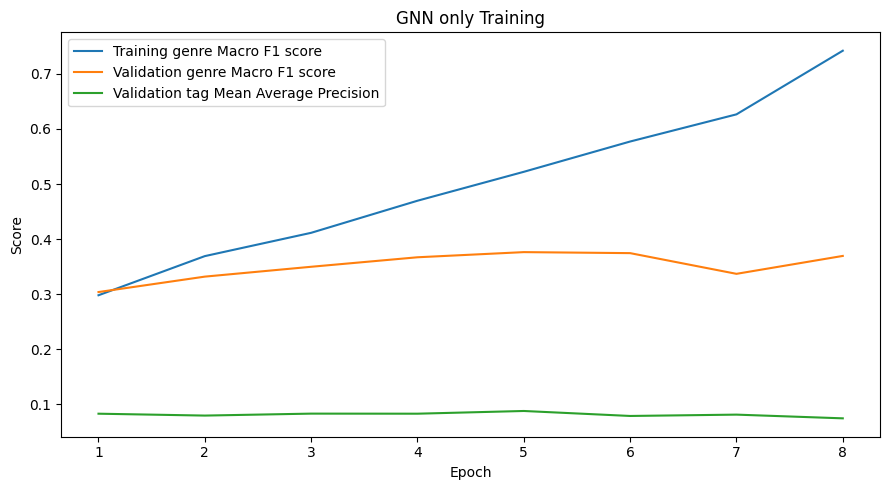

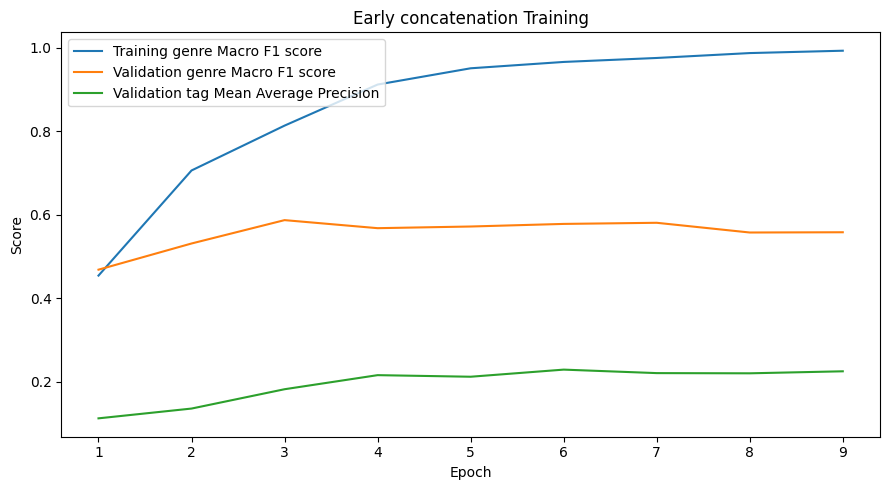

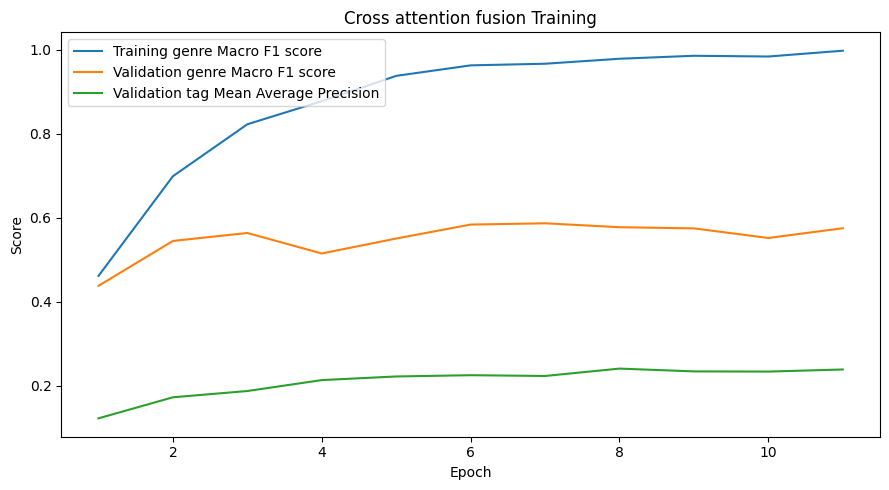

In [132]:
# CELL 44  Plot ablation training curves

for model_name, history in training_histories.items():
    display_name = MODEL_DISPLAY_NAMES[
        model_name
    ]

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        history["epoch"],
        history[
            "training_genre_macro_f1_score"
        ],
        label="Training genre Macro F1 score",
    )

    plt.plot(
        history["epoch"],
        history[
            "validation_genre_macro_f1_score"
        ],
        label="Validation genre Macro F1 score",
    )

    plt.plot(
        history["epoch"],
        history[
            "validation_tag_mean_average_precision"
        ],
        label="Validation tag Mean Average Precision",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(
        f"{display_name} Training"
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        PLOT_DIR
        / f"{model_name}_training.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

# Evaluate all four models

The tag probability threshold selected from validation data is reused unchanged on the held out test set.

In [133]:
# CELL 45  Evaluate every ablation on the held out test split

test_results = {}
test_raw = {}

for model_name in MODELS_TO_RUN:
    print()
    print(
        "Evaluating:",
        MODEL_DISPLAY_NAMES[
            model_name
        ],
    )

    model = trained_models[
        model_name
    ].to(DEVICE)

    raw = run_epoch(
        model,
        test_loader,
    )

    metrics = compute_all_metrics(
        raw["genre_true"],
        raw["genre_pred"],
        raw["tag_true"],
        raw["tag_probs"],
        tag_thresholds[
            model_name
        ],
    )

    test_results[
        model_name
    ] = metrics

    test_raw[
        model_name
    ] = raw

    print(
        "Genre accuracy:",
        f"{metrics['genre_accuracy']:.4f}",
    )

    print(
        "Genre Macro F1 score:",
        f"{metrics['genre_macro_f1']:.4f}",
    )

    print(
        "Genre Micro F1 score:",
        f"{metrics['genre_micro_f1']:.4f}",
    )

    print(
        "Tag Macro F1 score:",
        f"{metrics['tag_macro_f1']:.4f}",
    )

    print(
        "Tag Micro F1 score:",
        f"{metrics['tag_micro_f1']:.4f}",
    )

    print(
        "Tag Mean Average Precision:",
        f"{metrics['tag_mAP']:.4f}",
    )

    model.to(
        "cpu"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

comparison_rows = []

for model_name in MODELS_TO_RUN:
    metrics = test_results[
        model_name
    ]

    comparison_rows.append({
        "model": MODEL_DISPLAY_NAMES[
            model_name
        ],
        "model_key": model_name,
        "genre_accuracy": metrics[
            "genre_accuracy"
        ],
        "genre_macro_f1_score": metrics[
            "genre_macro_f1"
        ],
        "genre_micro_f1_score": metrics[
            "genre_micro_f1"
        ],
        "tag_macro_f1_score": metrics[
            "tag_macro_f1"
        ],
        "tag_micro_f1_score": metrics[
            "tag_micro_f1"
        ],
        "tag_mean_average_precision": metrics[
            "tag_mAP"
        ],
        "validation_selected_tag_probability_threshold": tag_thresholds[
            model_name
        ],
        "best_epoch": best_epochs[
            model_name
        ],
    })

comparison = pd.DataFrame(
    comparison_rows
)

display(
    comparison.round(4)
)

comparison.to_csv(
    METRICS_DIR
    / "task3_ablation_results.csv",
    index=False,
)


Evaluating: BERT only
Genre accuracy: 0.7386
Genre Macro F1 score: 0.4315
Genre Micro F1 score: 0.7386
Tag Macro F1 score: 0.1605
Tag Micro F1 score: 0.2249
Tag Mean Average Precision: 0.2063

Evaluating: GNN only
Genre accuracy: 0.6900
Genre Macro F1 score: 0.3814
Genre Micro F1 score: 0.6900
Tag Macro F1 score: 0.0479
Tag Micro F1 score: 0.0757
Tag Mean Average Precision: 0.0464

Evaluating: Early concatenation
Genre accuracy: 0.7476
Genre Macro F1 score: 0.3963
Genre Micro F1 score: 0.7476
Tag Macro F1 score: 0.1612
Tag Micro F1 score: 0.2005
Tag Mean Average Precision: 0.2313

Evaluating: Cross attention fusion
Genre accuracy: 0.7612
Genre Macro F1 score: 0.3980
Genre Micro F1 score: 0.7612
Tag Macro F1 score: 0.1155
Tag Micro F1 score: 0.0749
Tag Mean Average Precision: 0.2103


,model,model_key,genre_accuracy,genre_macro_f1_score,genre_micro_f1_score,tag_macro_f1_score,tag_micro_f1_score,tag_mean_average_precision,validation_selected_tag_probability_threshold,best_epoch
0,BERT only,bert_only,0.7386,0.4315,0.7386,0.1605,0.2249,0.2063,0.45,5
1,GNN only,gnn_only,0.6900,0.3814,0.6900,0.0479,0.0757,0.0464,0.30,5
2,Early concatenation,early_concat,0.7476,0.3963,0.7476,0.1612,0.2005,0.2313,0.65,6
3,Cross attention fusion,cross_attention,0.7612,0.3980,0.7612,0.1155,0.0749,0.2103,0.50,8


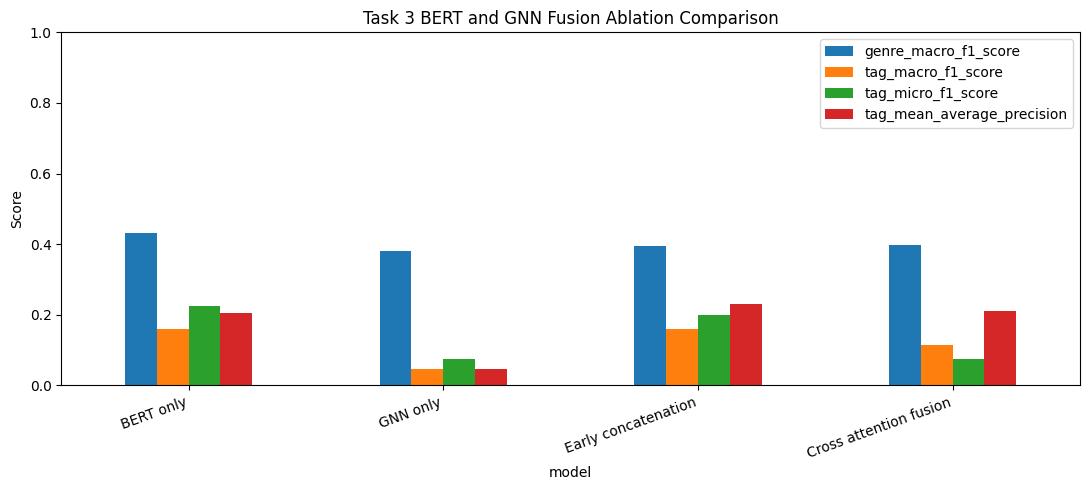

In [134]:
# CELL 46  Ablation comparison figure

plot_frame = (
    comparison
    .set_index("model")
    [
        [
            "genre_macro_f1_score",
            "tag_macro_f1_score",
            "tag_micro_f1_score",
            "tag_mean_average_precision",
        ]
    ]
)

axis = plot_frame.plot(
    kind="bar",
    figsize=(11, 5),
)

axis.set_ylim(
    0,
    1,
)

axis.set_ylabel(
    "Score"
)

axis.set_title(
    "Task 3 BERT and GNN Fusion Ablation Comparison"
)

plt.xticks(
    rotation=20,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "task3_ablation_comparison.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

# Detailed cross attention evaluation

The recommended cross attention model receives the detailed genre and tag analysis.

In [135]:
# ============================================================
# CELL 47 - CROSS-ATTENTION CLASSIFICATION REPORT
# ============================================================
cross_raw = test_raw[
    "cross_attention"
]

genre_report = pd.DataFrame(
    classification_report(
        cross_raw["genre_true"],
        cross_raw["genre_pred"],
        target_names=genre_names,
        output_dict=True,
        digits=4
    )
).T

display(genre_report)

genre_report.to_csv(
    RESULT_DIR
    / "cross_attention_genre_report.csv"
)

,precision,recall,f1-score,support
Blues,0.000000,0.000000,0.000000,8.000000
Classical,0.696629,1.000000,0.821192,62.000000
Country,0.000000,0.000000,0.000000,18.000000
Easy Listening,0.000000,0.000000,0.000000,6.000000
Electronic,0.881579,0.881579,0.881579,532.000000
Experimental,0.604839,0.604839,0.604839,124.000000
Folk,0.247934,0.576923,0.346821,52.000000
Hip-Hop,0.979592,0.800000,0.880734,120.000000
Instrumental,0.333333,0.040541,0.072289,74.000000
International,0.000000,0.000000,0.000000,2.000000


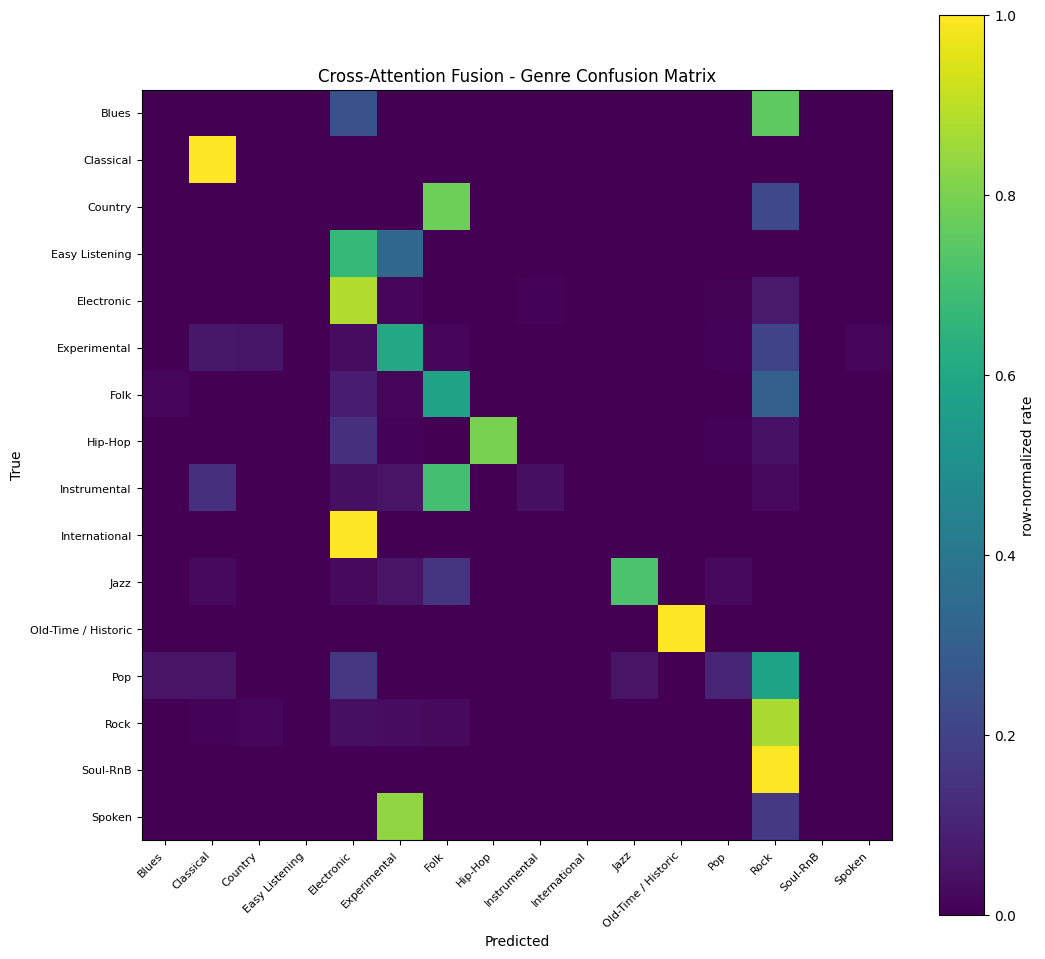

In [136]:
# ============================================================
# CELL 48 - GENRE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(
    cross_raw["genre_true"],
    cross_raw["genre_pred"]
)

cm_norm = (
    cm
    / np.maximum(
        cm.sum(axis=1, keepdims=True),
        1
    )
)

fig, ax = plt.subplots(
    figsize=(11, 10)
)

im = ax.imshow(
    cm_norm,
    vmin=0,
    vmax=1
)

fig.colorbar(
    im,
    ax=ax,
    label="row-normalized rate"
)

ax.set_xticks(
    range(NUM_GENRES)
)
ax.set_yticks(
    range(NUM_GENRES)
)

ax.set_xticklabels(
    genre_names,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_yticklabels(
    genre_names,
    fontsize=8
)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(
    "Cross-Attention Fusion - Genre Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "cross_attention_genre_confusion.png",
    dpi=180
)

plt.show()

In [137]:
# CELL 49  Per tag Cross Attention metrics

threshold = tag_thresholds[
    "cross_attention"
]

tag_true = cross_raw[
    "tag_true"
]

tag_probs = cross_raw[
    "tag_probs"
]

tag_pred = (
    tag_probs
    >= threshold
).astype(int)

per_tag_average_precision = (
    average_precision_score(
        tag_true,
        tag_probs,
        average=None,
    )
)

per_tag_f1_score = np.array([
    f1_score(
        tag_true[:, tag_index],
        tag_pred[:, tag_index],
        zero_division=0,
    )
    for tag_index in range(
        NUM_TAGS
    )
])

tag_result_df = pd.DataFrame({
    "tag": TAG_VOCAB,
    "f1_score": per_tag_f1_score,
    "average_precision_area_under_precision_recall_curve": per_tag_average_precision,
    "test_positive_examples": (
        tag_true
        .sum(axis=0)
        .astype(int)
    ),

    # Compatibility columns used by the Task 4 comparison notebook.
    "F1": per_tag_f1_score,
    "AUC_PR_AP": per_tag_average_precision,
}).sort_values(
    "average_precision_area_under_precision_recall_curve",
    ascending=False,
)

display(
    tag_result_df
)

tag_result_df.to_csv(
    METRICS_DIR
    / "cross_attention_per_tag_metrics.csv",
    index=False,
)

,tag,f1_score,average_precision_area_under_precision_recall_curve,test_positive_examples,F1,AUC_PR_AP
38,dubstep,0.666667,1.000000,1,0.666667,1.000000
44,terror,1.000000,1.000000,2,1.000000,1.000000
16,hip hop,0.285714,1.000000,1,0.285714,1.000000
22,halloween,0.888889,0.966667,5,0.888889,0.966667
21,chip music,0.666667,0.950000,4,0.666667,0.950000
35,dub,0.750000,0.916667,3,0.750000,0.916667
6,horror,0.666667,0.858824,5,0.666667,0.858824
19,chiptune,0.113208,0.662331,46,0.113208,0.662331
39,micromusic,0.000000,0.638709,43,0.000000,0.638709
5,electronica,0.173913,0.566667,2,0.173913,0.566667


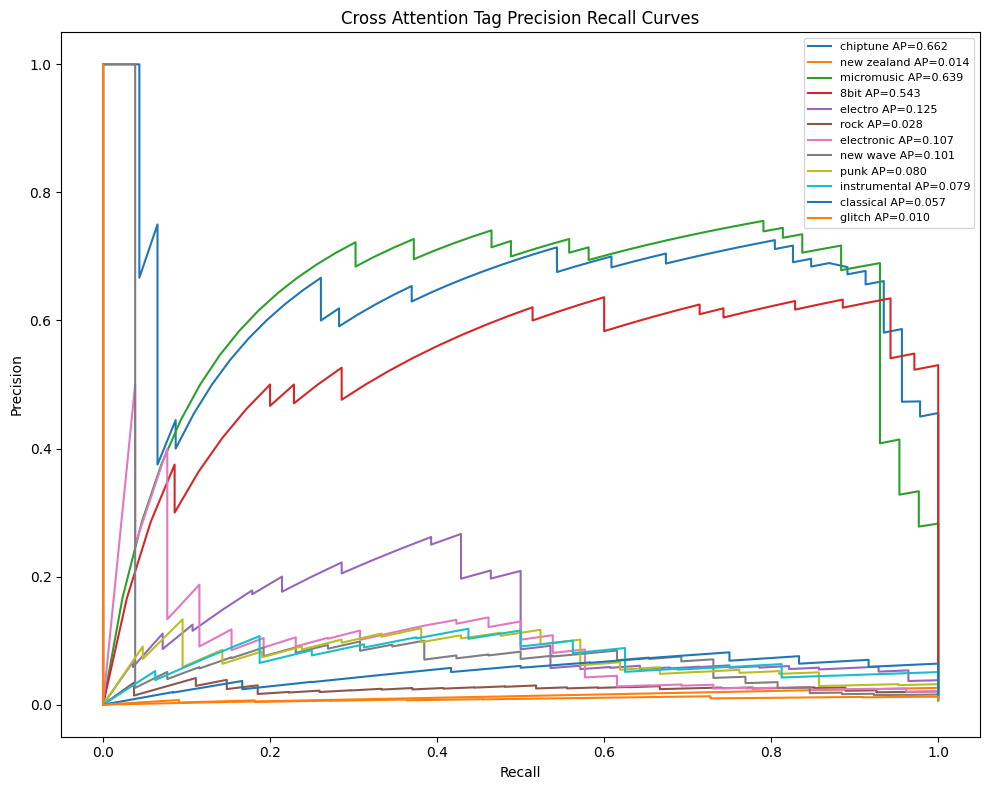

In [138]:
# ============================================================
# CELL 50 - TAG PRECISION-RECALL CURVES
# ============================================================
# Plot the 12 most frequent test tags for readability.
freq_order = np.argsort(
    -tag_true.sum(axis=0)
)[:12]

plt.figure(
    figsize=(10, 8)
)

for k in freq_order:
    precision, recall, _ = (
        precision_recall_curve(
            tag_true[:, k],
            tag_probs[:, k]
        )
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{TAG_VOCAB[k]} "
            f"AP={per_tag_average_precision[k]:.3f}"
        )
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Cross Attention Tag Precision Recall Curves"
)
plt.legend(
    fontsize=8
)
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "cross_attention_tag_pr_curves.png",
    dpi=180
)

plt.show()

# Fused representation visualization

Held out cross attention fusion embeddings are standardized, reduced with Principal Component Analysis, and visualized with t distributed Stochastic Neighbor Embedding.

A cosine silhouette score is also calculated in the standardized embedding space.

In [139]:
# ============================================================
# CELL 51 - EXTRACT CROSS-ATTENTION FUSION EMBEDDINGS
# ============================================================
cross_model = trained_models[
    "cross_attention"
].to(DEVICE)

cross_model.eval()

fusion_embeddings = []
fusion_genres = []
fusion_tags = []
fusion_track_ids = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)

        out = cross_model(
            batch
        )

        fusion_embeddings.append(
            out["embedding"]
            .cpu().numpy()
        )

        fusion_genres.extend(
            batch.y.view(-1)
            .cpu().numpy()
        )

        fusion_tags.extend(
            batch.tag_y
            .cpu().numpy()
        )

        fusion_track_ids.extend(
            batch.track_id.view(-1)
            .cpu().numpy()
        )

fusion_embeddings = np.concatenate(
    fusion_embeddings,
    axis=0
)

fusion_genres = np.asarray(
    fusion_genres
)

fusion_tags = np.asarray(
    fusion_tags
)

fusion_track_ids = np.asarray(
    fusion_track_ids
)

fusion_std = StandardScaler().fit_transform(
    fusion_embeddings
)

fusion_silhouette = silhouette_score(
    fusion_std,
    fusion_genres,
    metric="cosine"
)

print(
    "Fusion embedding shape:",
    fusion_embeddings.shape
)

print(
    "Genre cosine silhouette:",
    round(
        float(
            fusion_silhouette
        ),
        4
    )
)

Fusion embedding shape: (1771, 256)
Genre cosine silhouette: 0.0965


In [140]:
# ============================================================
# CELL 52 - PCA -> t-SNE
# ============================================================
pca_dim = min(
    50,
    fusion_std.shape[1],
    fusion_std.shape[0] - 1
)

fusion_pca = PCA(
    n_components=pca_dim,
    random_state=SEED
).fit_transform(
    fusion_std
)

perplexity = min(
    30,
    max(
        5,
        len(fusion_pca) // 20
    )
)

fusion_tsne = TSNE(
    n_components=2,
    random_state=SEED,
    init="pca",
    learning_rate="auto",
    perplexity=perplexity,
    max_iter=1500
).fit_transform(
    fusion_pca
)

print(
    "t-SNE:",
    fusion_tsne.shape
)

t-SNE: (1771, 2)


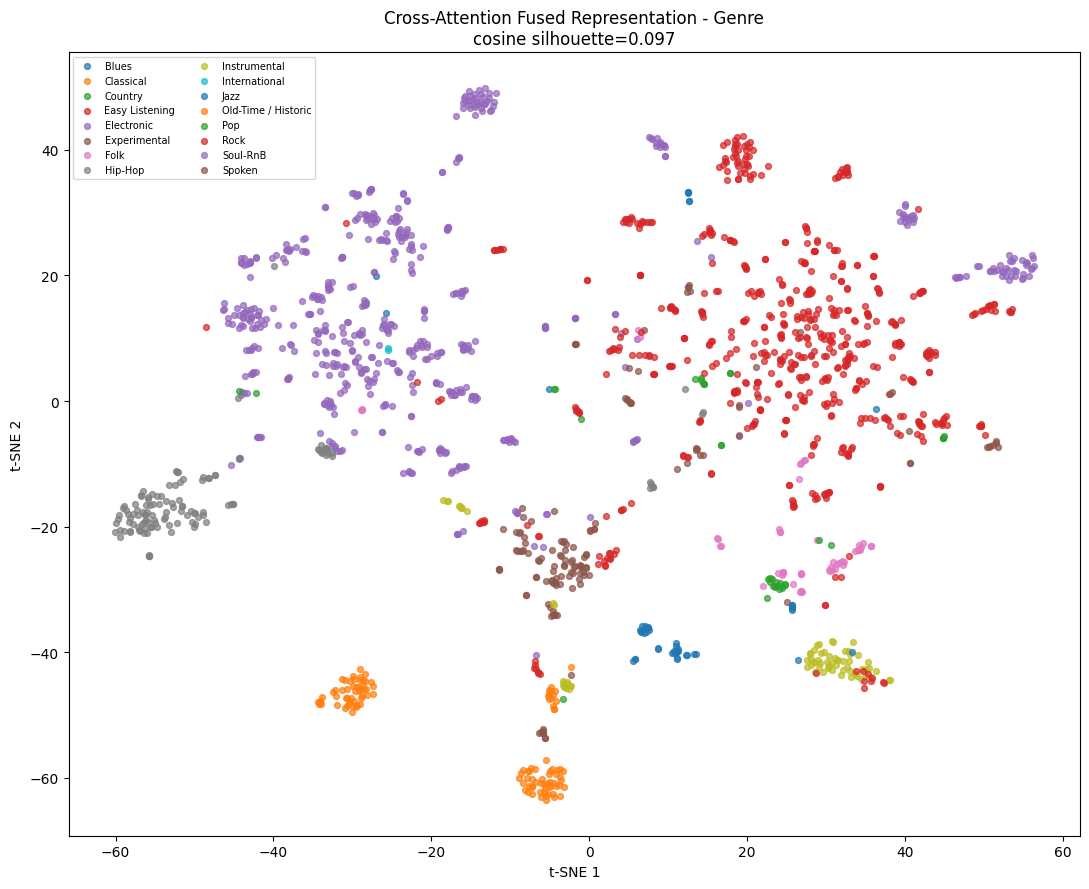

In [141]:
# ============================================================
# CELL 53 - t-SNE COLORED BY GENRE
# ============================================================
plt.figure(
    figsize=(11, 9)
)

for c in range(NUM_GENRES):
    mask = (
        fusion_genres == c
    )

    plt.scatter(
        fusion_tsne[
            mask, 0
        ],
        fusion_tsne[
            mask, 1
        ],
        s=18,
        alpha=0.70,
        label=idx2genre[c]
    )

plt.title(
    "Cross-Attention Fused Representation - Genre\n"
    f"cosine silhouette={fusion_silhouette:.3f}"
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(
    fontsize=7,
    ncol=2
)
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "fusion_tsne_genre.png",
    dpi=180
)

plt.show()

# Mood like tag visualization

FMA does not provide standardized valence and arousal labels.

The notebook does not invent emotion labels.

If real mood like tags are present in the selected FMA tag vocabulary, they are used only for an exploratory visualization.

In [142]:
# ============================================================
# CELL 54 - OPTIONAL MOOD-LIKE TAG t-SNE
# ============================================================
MOOD_WORDS = {
    "happy", "sad", "dark", "chill", "chilled",
    "relaxing", "relaxed", "mellow", "energetic",
    "calm", "dreamy", "melancholic", "melancholy",
    "aggressive", "romantic", "ambient",
}

mood_tag_indices = [
    i
    for i, tag in enumerate(TAG_VOCAB)
    if tag in MOOD_WORDS
]

print(
    "Mood-like selected tags:",
    [
        TAG_VOCAB[i]
        for i in mood_tag_indices
    ]
)

if mood_tag_indices:
    # Assign first true mood-like tag, otherwise "none".
    mood_label = []

    for row in fusion_tags:
        hits = [
            TAG_VOCAB[i]
            for i in mood_tag_indices
            if row[i] > 0.5
        ]

        mood_label.append(
            hits[0]
            if hits
            else "none"
        )

    mood_label = np.asarray(
        mood_label
    )

    # Plot only tags with enough examples.
    counts = pd.Series(
        mood_label
    ).value_counts()

    keep_labels = [
        x
        for x, n in counts.items()
        if x != "none" and n >= 10
    ]

    if keep_labels:
        plt.figure(
            figsize=(10, 8)
        )

        for label in keep_labels:
            mask = (
                mood_label == label
            )

            plt.scatter(
                fusion_tsne[
                    mask, 0
                ],
                fusion_tsne[
                    mask, 1
                ],
                s=25,
                alpha=0.7,
                label=label
            )

        plt.title(
            "Fused Representation - Observed Mood-like FMA Tags"
        )

        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            PLOT_DIR
            / "fusion_tsne_mood_like_tags.png",
            dpi=180
        )

        plt.show()

    else:
        print(
            "No mood-like tag has enough test positives "
            "for a meaningful plot."
        )

else:
    print(
        "No explicit mood-like tags are present in the "
        "selected top-tag vocabulary. "
        "This is a property of FMA metadata, not an error."
    )

Mood-like selected tags: ['ambient']
No mood-like tag has enough test positives for a meaningful plot.


In [143]:
# ============================================================
# CELL 55 - SAVE t-SNE COORDINATES
# ============================================================
tsne_df = pd.DataFrame({
    "track_id":
        fusion_track_ids,

    "genre":
        [
            idx2genre[int(y)]
            for y in fusion_genres
        ],

    "tsne_1":
        fusion_tsne[:, 0],

    "tsne_2":
        fusion_tsne[:, 1],
})

tsne_df.to_csv(
    RESULT_DIR
    / "fusion_tsne_coordinates.csv",
    index=False
)

display(
    tsne_df.head()
)

,track_id,genre,tsne_1,tsne_2
0,181,Rock,-21.863714,3.108657
1,564,Rock,41.668304,30.564638
2,734,Soul-RnB,52.836800,19.961603
3,735,Soul-RnB,56.132118,21.191221
4,736,Soul-RnB,52.977661,20.815174


# Three cross attention case studies

Each case shows the true and predicted genre, true and predicted tags, most attended text tokens, semantic metadata text, and strongest non local graph links.

The text is described as semantic metadata because FMA does not provide aligned captions or lyrics for every track.

In [144]:
# ============================================================
# CELL 56 - CASE-STUDY HELPERS
# ============================================================
def top_predicted_tags(
    probs,
    threshold,
    n=8
):
    order = np.argsort(
        probs
    )[::-1]

    chosen = [
        i for i in order
        if probs[i] >= threshold
    ][:n]

    if not chosen:
        chosen = order[:min(n, 5)]

    return [
        (
            TAG_VOCAB[i],
            float(probs[i])
        )
        for i in chosen
    ]


def true_selected_tags(
    vector
):
    return [
        TAG_VOCAB[i]
        for i, v in enumerate(vector)
        if v > 0.5
    ]


def attention_tokens(
    input_ids,
    attention,
    mask,
    top_k=12
):
    tokens = tokenizer.convert_ids_to_tokens(
        input_ids.tolist()
    )

    valid = []

    for i, (
        tok,
        score,
        keep
    ) in enumerate(
        zip(
            tokens,
            attention.tolist(),
            mask.tolist()
        )
    ):
        if not keep:
            continue

        if tok in tokenizer.all_special_tokens:
            continue

        valid.append(
            (
                tok,
                float(score),
                i
            )
        )

    valid = sorted(
        valid,
        key=lambda x: x[1],
        reverse=True
    )

    return valid[:top_k]

In [145]:
# ============================================================
# CELL 57 - RUN ONE CROSS-ATTENTION CASE
# ============================================================
def run_case_study(
    dataset_index,
    case_number,
):
    single_loader = GeoDataLoader(
        [
            test_ds[
                dataset_index
            ]
        ],
        batch_size=1,
        shuffle=False
    )

    batch = next(
        iter(
            single_loader
        )
    ).to(DEVICE)

    cross_model.eval()

    with torch.no_grad():
        out = cross_model(
            batch,
            return_aux=True
        )

    genre_prob = torch.softmax(
        out["genre_logits"],
        dim=1
    )[0].cpu().numpy()

    tag_prob = torch.sigmoid(
        out["tag_logits"]
    )[0].cpu().numpy()

    predicted_genre = int(
        np.argmax(
            genre_prob
        )
    )

    tid = int(
        batch.track_id.item()
    )

    row = test_meta[
        test_meta["track_id"] == tid
    ].iloc[0]

    true_tag_vec = (
        batch.tag_y[0]
        .cpu().numpy()
    )

    att = (
        out["attention"][0]
        .cpu().numpy()
    )

    token_info = attention_tokens(
        batch.input_ids[0].cpu(),
        att,
        batch.attention_mask[0].cpu(),
        top_k=15
    )

    print("=" * 90)
    print("CASE", case_number)
    print("Track ID:", tid)
    print("True genre:", row["genre"])
    print(
        "Predicted genre:",
        idx2genre[predicted_genre],
        "| p=",
        round(
            float(
                genre_prob[
                    predicted_genre
                ]
            ),
            4
        )
    )

    print(
        "\nTrue selected tags:",
        true_selected_tags(
            true_tag_vec
        )
    )

    print(
        "Predicted tags:",
        top_predicted_tags(
            tag_prob,
            tag_thresholds[
                "cross_attention"
            ]
        )
    )

    print(
        "\nTop cross-attended BERT tokens:"
    )

    display(
        pd.DataFrame(
            token_info,
            columns=[
                "token",
                "attention",
                "position"
            ]
        )
    )

    print(
        "\nSemantic text:"
    )

    print(
        row["text"][:1800]
    )

    # ---------- graph plot ----------
    g = torch.load(
        GRAPH_DIR
        / f"{tid:06d}.pt",
        weights_only=False
    )

    G = nx.Graph()

    G.add_nodes_from(
        range(g.num_nodes)
    )

    edge_rows = []

    for (
        a,
        b
    ), edge_type, weight in zip(
        g.edge_index.t().numpy(),
        g.edge_type.numpy(),
        g.edge_weight.numpy()
    ):
        a = int(a)
        b = int(b)

        if a > b:
            continue

        G.add_edge(
            a,
            b
        )

        edge_rows.append({
            "source": a,
            "target": b,
            "type":
                "temporal"
                if int(edge_type) == 0
                else "similarity",
            "weight":
                float(weight),
        })

    pos = nx.spring_layout(
        G,
        seed=SEED
    )

    plt.figure(
        figsize=(8, 6)
    )

    nx.draw_networkx(
        G,
        pos,
        node_size=550,
        font_size=8
    )

    plt.title(
        f"Case {case_number}: "
        f"Track {tid} - Audio Structure Graph"
    )

    plt.axis("off")
    plt.tight_layout()

    out_plot = (
        CASE_DIR
        / f"case_{case_number}_graph.png"
    )

    plt.savefig(
        out_plot,
        dpi=180
    )

    plt.show()

    edge_df = pd.DataFrame(
        edge_rows
    )

    similarity_df = (
        edge_df[
            edge_df["type"]
            == "similarity"
        ]
        .sort_values(
            "weight",
            ascending=False
        )
        .head(10)
    )

    print(
        "\nStrongest non-local graph links:"
    )

    display(
        similarity_df
    )

    case_json = {
        "case": case_number,
        "track_id": tid,
        "true_genre": row["genre"],
        "predicted_genre":
            idx2genre[predicted_genre],
        "true_tags":
            true_selected_tags(
                true_tag_vec
            ),
        "predicted_tags":
            top_predicted_tags(
                tag_prob,
                tag_thresholds[
                    "cross_attention"
                ]
            ),
        "top_attention_tokens":
            [
                {
                    "token": t,
                    "attention": s,
                    "position": p
                }
                for t, s, p
                in token_info
            ],
        "text": row["text"],
        "strong_similarity_edges":
            similarity_df.to_dict(
                "records"
            ),
    }

    with open(
        CASE_DIR
        / f"case_{case_number}.json",
        "w"
    ) as f:
        json.dump(
            case_json,
            f,
            indent=2
        )

    return case_json

In [146]:
# ============================================================
# CELL 58 - AUTOMATICALLY CHOOSE 3 INFORMATIVE CASES
# ============================================================
cross_genre_correct = (
    cross_raw["genre_true"]
    ==
    cross_raw["genre_pred"]
)

tag_positive_count = (
    cross_raw["tag_true"].sum(
        axis=1
    )
)

# Prefer correctly classified examples with at least one selected tag.
candidate_positions = np.where(
    cross_genre_correct
    &
    (tag_positive_count > 0)
)[0]

if len(candidate_positions) < 3:
    candidate_positions = np.arange(
        min(
            3,
            len(test_ds)
        )
    )
else:
    # Spread examples through the test set.
    candidate_positions = candidate_positions[
        np.linspace(
            0,
            len(candidate_positions) - 1,
            3
        ).astype(int)
    ]

print(
    "Selected test positions:",
    candidate_positions
)

Selected test positions: [ 173  488 1664]


CASE 1
Track ID: 13814
True genre: Folk
Predicted genre: Folk | p= 0.9538

True selected tags: ['clinical archives']
Predicted tags: [('experimental', 0.03720401972532272), ('hip hop', 0.010968047194182873), ('instrumental', 0.008626656606793404), ('clinical archives', 0.0033879359252750874), ('breakcore', 0.002890203380957246)]

Top cross-attended BERT tokens:


,token,attention,position
0,stones,0.278831,60
1,stones,0.167402,117
2,##hir,0.083771,29
3,##hir,0.077972,97
4,##hir,0.070788,40
5,##hir,0.042183,16
6,of,0.021403,42
7,of,0.020343,31
8,of,0.019781,99
9,prehistoric,0.019225,57



Semantic text:
track title: Red Roses. album title: Different World. artist: Menhirs of Er Grah. artist descriptors: menhirs of er grah. artist biography: Menhirs of Er Grah (Tom Carter) is a folk band named after some prehistoric standing-stones in France. Tom Carter lives in London, and has released a number of lo-fi/electronica albums under the anagram of March Rosetta.. album information: Menhirs of Er Grah (Tom Carter) is a folk band named after some prehistoric standing-stones in France. The album was made in 7 days – a day to write and record each of the songs from scratch, and then a day to mix and master them all. Voice and guitar parts were recorded simultaneously into the same mic, and then a second guitar part was recorded as another track on-top. Tom Carter lives in London, and has released a number of lo-fi/electronica albums under the anagram of March Rosetta.


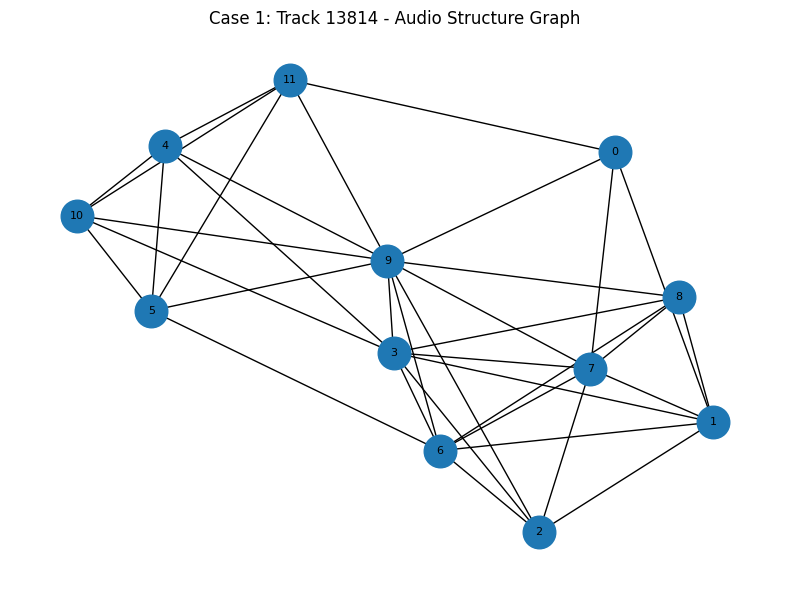


Strongest non-local graph links:


,source,target,type,weight
20,4,9,similarity,0.995446
21,4,10,similarity,0.994252
14,3,6,similarity,0.992702
25,5,10,similarity,0.990974
11,2,7,similarity,0.987982
22,4,11,similarity,0.987935
34,9,11,similarity,0.987567
17,3,9,similarity,0.987500
7,1,7,similarity,0.985835
24,5,9,similarity,0.984636


CASE 2
Track ID: 37962
True genre: Electronic
Predicted genre: Electronic | p= 0.9638

True selected tags: ['dance']
Predicted tags: [('electronic', 0.08915437757968903), ('electro', 0.020106980577111244), ('idm', 0.013176042586565018), ('dance', 0.012725786305963993), ('era 1', 0.010848668403923512)]

Top cross-attended BERT tokens:


,token,attention,position
0,music,0.479022,50
1,electronic,0.060949,49
2,peter,0.060495,36
3,##nic,0.040566,100
4,of,0.032179,113
5,##pping,0.028303,115
6,peter,0.025952,30
7,peter,0.023992,20
8,of,0.015280,48
9,composer,0.012277,47



Semantic text:
track title: Do u wanna shake hands?. album title: Why not?. artist: Peter Sharp. artist descriptors: italy, peter sharp. artist biography: Peter Sharp aka Piero Acuto is an independent Italian composer of electronic music and he's also an experienced graphic designer and conceptual thinker . He was drummer and percussionist of the band Changin Club and member of the electronic fanzine Torino Disco Cross. H e has collaborated, for different projects, with: Papanico (Africa Unite) Roby Vitari (The Art of Zapping - Kutfaces - Hollywood Killerz), Doc Delavie (Doctor Jazz Universal Remedy), Righeira, Paduraru, Y il bisbetico dopato, Stokka & Mad Buddy, The Art of Zapping, Roger Rama, Master Mp3, Frankie Boy, Luca Ragagnin, Lou-c, Dana & the Blue Family Stone, Giorgio Curti (SKK Project), Kikskoda, Rossella Cangini, Giorgio Licalzi, Luca Minchillo R.I.P. (Radio7, Radio Nova - Paris).


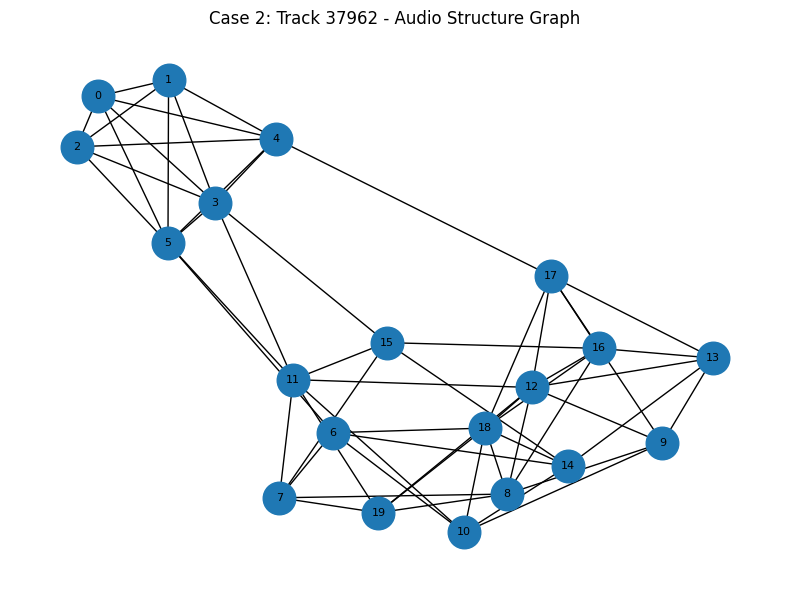


Strongest non-local graph links:


,source,target,type,weight
3,0,4,similarity,0.999948
30,8,16,similarity,0.999724
44,12,16,similarity,0.997710
29,8,12,similarity,0.997443
36,9,17,similarity,0.994079
52,14,18,similarity,0.994055
38,10,14,similarity,0.993983
22,6,14,similarity,0.993216
14,3,11,similarity,0.993200
39,10,18,similarity,0.992776


CASE 3
Track ID: 144595
True genre: Electronic
Predicted genre: Electronic | p= 0.5435

True selected tags: ['downtempo']
Predicted tags: [('noise', 0.02252616547048092), ('experimental', 0.018872542306780815), ('new zealand', 0.01453874260187149), ('instrumental', 0.01379770040512085), ('electronic', 0.008023451082408428)]

Top cross-attended BERT tokens:


,token,attention,position
0,cat,0.219943,82
1,michael,0.204078,67
2,cat,0.180010,43
3,cat,0.052787,32
4,cat,0.042426,20
5,##scu,0.038174,93
6,##io,0.033385,55
7,-,0.033119,77
8,ale,0.030367,78
9,-,0.018138,66



Semantic text:
track title: Fioletovaya Tape. album title: The Big Numbers. artist: Trillion Catz. artist descriptors: darkwave, trillion catz. artist biography: Proyecto Trillion Catz es una formación medio alemán y medio rusa, formada por una sola persona - Michael Nordhagen- de origen ruso-alemán. Trillion Catz empezó su actividad en Moscú, pero finalmente se trasladó a Berlín y a otros países europeos. En los concierto e directo, la banda utiliza tanto guitarras como percusión. El álbum 'The Big Numbers' fue grabado en 2016 en San Petersburgo, Rusia. En estos momentos la banda está trabajando para que sus directos sean programados y poderlos desarrollar dentro del marco europeo. Project Trillion catz this equipment from German and Russian. The group consists of one person - Michael Nordhagen- has a Russian-German origin. Trillion Catz based in Moscow and eventually moved to Berlin and other European countries. In concert, the band performs the songs with live guitars and drums. Al

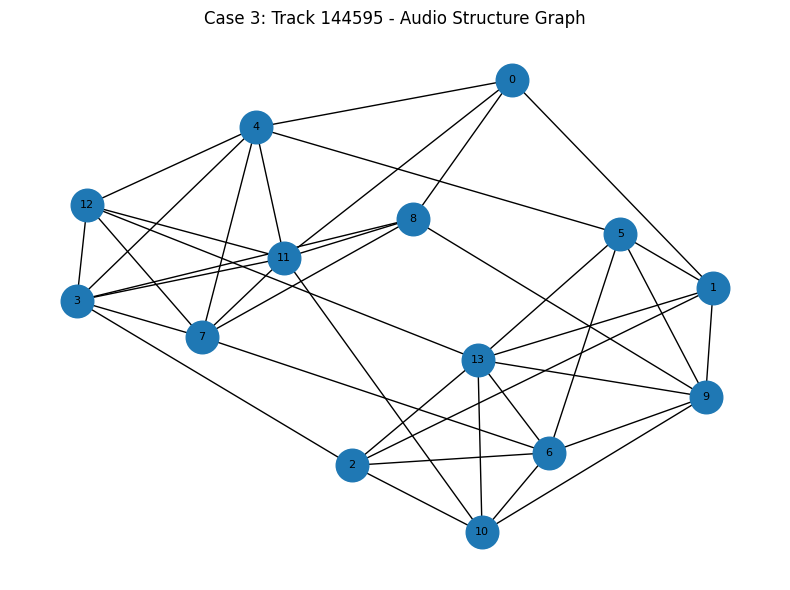


Strongest non-local graph links:


,source,target,type,weight
2,0,8,similarity,0.999772
13,3,7,similarity,0.999762
5,1,5,similarity,0.999582
34,9,13,similarity,0.999364
26,6,10,similarity,0.999353
9,2,6,similarity,0.999348
3,0,11,similarity,0.999108
29,7,11,similarity,0.999086
15,3,11,similarity,0.999014
32,8,11,similarity,0.998951


In [147]:
# ============================================================
# CELL 59 - GENERATE THREE REQUIRED CASE STUDIES
# ============================================================
case_studies = []

for case_number, dataset_index in enumerate(
    candidate_positions[:3],
    start=1
):
    case_studies.append(
        run_case_study(
            int(dataset_index),
            case_number
        )
    )

# Save cross attention test predictions

In [148]:
# ============================================================
# CELL 60 - SAVE CROSS-ATTENTION TEST PREDICTIONS
# ============================================================
cross_tag_pred = (
    cross_raw["tag_probs"]
    >=
    tag_thresholds[
        "cross_attention"
    ]
).astype(int)

prediction_rows = []

for i, tid in enumerate(
    cross_raw["track_ids"]
):
    prediction_rows.append({
        "track_id":
            int(tid),

        "true_genre":
            idx2genre[
                int(
                    cross_raw[
                        "genre_true"
                    ][i]
                )
            ],

        "pred_genre":
            idx2genre[
                int(
                    cross_raw[
                        "genre_pred"
                    ][i]
                )
            ],

        "true_tags":
            " | ".join(
                true_selected_tags(
                    cross_raw[
                        "tag_true"
                    ][i]
                )
            ),

        "pred_tags":
            " | ".join(
                [
                    TAG_VOCAB[k]
                    for k in range(
                        NUM_TAGS
                    )
                    if cross_tag_pred[
                        i, k
                    ]
                ]
            ),
    })

prediction_df = pd.DataFrame(
    prediction_rows
)

display(
    prediction_df.head(20)
)

prediction_df.to_csv(
    EXAMPLES_DIR
    / "cross_attention_test_predictions.csv",
    index=False
)

,track_id,true_genre,pred_genre,true_tags,pred_tags
0,181,Rock,Electronic,,
1,564,Rock,Rock,,new wave
2,734,Soul-RnB,Rock,,
3,735,Soul-RnB,Rock,,
4,736,Soul-RnB,Rock,,
5,737,Soul-RnB,Rock,,
6,738,Soul-RnB,Rock,,
7,739,Soul-RnB,Rock,,
8,740,Soul-RnB,Rock,,
9,741,Soul-RnB,Rock,,


# Optional graph coherence analysis

Graph coherence measures how often connected nodes have similar learned GraphSAGE representations.

It is an additional analysis metric, not the main Task 3 score.

In [149]:
# ============================================================
# CELL 61 - GRAPH COHERENCE
# ============================================================
def graph_coherence(
    fusion_model,
    loader,
    tau_h=0.5,
    max_graphs=500
):
    fusion_model.eval()

    coherent = 0
    total = 0
    seen_graphs = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(
                DEVICE
            )

            h = (
                fusion_model
                .graph_encoder
                .forward_nodes(
                    batch
                )
            )

            h = F.normalize(
                h,
                dim=1
            )

            src, dst = (
                batch.edge_index
            )

            cosine = (
                h[src] * h[dst]
            ).sum(
                dim=1
            )

            coherent += int(
                (
                    cosine > tau_h
                ).sum()
            )

            total += (
                cosine.numel()
            )

            seen_graphs += (
                batch.num_graphs
            )

            if seen_graphs >= max_graphs:
                break

    return coherent / max(
        total,
        1
    )

coherence = graph_coherence(
    cross_model,
    test_loader
)

print(
    "Learned graph coherence:",
    round(
        float(coherence),
        4
    )
)

Learned graph coherence: 0.8647


# Save representative graph samples

The final GitHub folder stores 24 representative PyTorch Geometric graph files.

The complete raw graph cache stays outside the download folder.

In [150]:
# CELL 62  Copy 24 representative graph samples

for existing_file in SAMPLE_DIR.glob(
    "*.pt"
):
    existing_file.unlink()

sample_rows = []

# First choose one graph per genre.
for genre in genre_names:
    candidates = (
        paired_meta[
            paired_meta["genre"]
            == genre
        ]
        .sort_values(
            "track_id"
        )
    )

    if len(candidates):
        sample_rows.append(
            candidates.iloc[0]
        )

# Fill the remaining positions from unused valid tracks.
selected_ids = {
    int(row["track_id"])
    for row in sample_rows
}

remaining = (
    paired_meta[
        ~paired_meta[
            "track_id"
        ].isin(
            selected_ids
        )
    ]
    .sort_values(
        [
            "genre",
            "track_id",
        ]
    )
)

for _, row in remaining.iterrows():
    if len(sample_rows) >= 24:
        break

    sample_rows.append(
        row
    )

graph_sample_manifest_rows = []

for row in sample_rows[:24]:
    track_id = int(
        row["track_id"]
    )

    source_graph = (
        GRAPH_DIR
        / f"{track_id:06d}.pt"
    )

    destination_graph = (
        SAMPLE_DIR
        / source_graph.name
    )

    shutil.copy2(
        source_graph,
        destination_graph,
    )

    graph_sample_manifest_rows.append({
        "file": source_graph.name,
        "track_id": track_id,
        "genre": row["genre"],
        "split": row["split"],
    })

graph_sample_manifest = pd.DataFrame(
    graph_sample_manifest_rows
)

graph_sample_manifest.to_csv(
    SAMPLE_DIR
    / "graph_sample_manifest.csv",
    index=False,
)

number_of_graph_samples = len(
    list(
        SAMPLE_DIR.glob(
            "*.pt"
        )
    )
)

print(
    "Saved graph sample files:",
    number_of_graph_samples,
)

assert (
    number_of_graph_samples
    >= 20
), "At least 20 graph sample files are required."

Saved graph sample files: 24


In [151]:
# CELL 63  Audio decoding audit

audio_audit_df = pd.DataFrame(
    AUDIO_AUDIT
)

if len(
    audio_audit_df
):
    audio_audit_df = (
        audio_audit_df
        .drop_duplicates(
            subset=["track_id"],
            keep="last",
        )
    )

audio_audit_df.to_csv(
    METRICS_DIR
    / "audio_decode_audit.csv",
    index=False,
)

print(
    "Audited tracks:",
    len(
        audio_audit_df
    ),
)

if len(
    audio_audit_df
):
    display(
        audio_audit_df[
            "backend"
        ].value_counts()
    )

    numeric_audio_audit = (
        audio_audit_df
        .select_dtypes(
            include=[np.number]
        )
    )

    if len(
        numeric_audio_audit.columns
    ) > 0:
        display(
            numeric_audio_audit.describe()
        )

Audited tracks: 16984


backend
librosa    16984
Name: count, dtype: int64

,track_id,seconds_before_padding,peak,rms
count,16984.000000,16984.000000,16984.000000,16984.000000
mean,74328.766722,29.986740,0.862188,0.193449
std,44701.523903,0.023298,0.228147,0.096898
min,3.000000,27.338231,0.000071,0.000024
25%,34998.750000,29.976599,0.753967,0.121635
50%,70457.500000,29.976599,0.943191,0.185968
75%,115258.500000,30.000000,1.002743,0.254215
max,155314.000000,30.000000,2.538814,0.913544


# Save final metrics and experiment configuration

In [152]:
# CELL 64  Save final metrics and experiment configuration

metrics_json = {}

for model_name, result in test_results.items():
    metrics_json[
        model_name
    ] = {
        "genre_accuracy": float(
            result[
                "genre_accuracy"
            ]
        ),
        "genre_macro_f1_score": float(
            result[
                "genre_macro_f1"
            ]
        ),
        "genre_micro_f1_score": float(
            result[
                "genre_micro_f1"
            ]
        ),
        "tag_macro_f1_score": float(
            result[
                "tag_macro_f1"
            ]
        ),
        "tag_micro_f1_score": float(
            result[
                "tag_micro_f1"
            ]
        ),
        "tag_mean_average_precision": float(
            result[
                "tag_mAP"
            ]
        ),
        "validation_selected_tag_probability_threshold": float(
            tag_thresholds[
                model_name
            ]
        ),
        "best_epoch": int(
            best_epochs[
                model_name
            ]
        ),
    }

metrics_json[
    "cross_attention_graph_coherence"
] = float(
    coherence
)

metrics_json[
    "cross_attention_genre_cosine_silhouette_score"
] = float(
    fusion_silhouette
)

with open(
    METRICS_DIR
    / "final_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metrics_json,
        file,
        indent=2,
    )

config = {
    "dataset": "FMA medium",
    "official_fma_split": True,
    "targets": {
        "genre": (
            f"{NUM_GENRES} class genre_top"
        ),
        "tags": (
            f"top {NUM_TAGS} track tags selected from training only"
        ),
    },
    "text_source": [
        "track title",
        "album title",
        "artist name",
        "artist biography",
        "album information",
        "artist tags after leakage filtering",
        "album tags after leakage filtering",
    ],
    "track_tags_used_as_text_input": False,
    "sample_rate": SR,
    "duration_seconds": DURATION,
    "segmentation": (
        "Four beat groups with fixed three second fallback"
    ),
    "node_features": (
        "MFCC chroma spectral contrast tonnetz and spectral statistics using segment mean and standard deviation"
    ),
    "node_feature_dimension": 100,
    "edge_types": [
        "temporal adjacency",
        "cosine similarity",
    ],
    "similarity_threshold": SIM_THRESHOLD,
    "similarity_top_k": SIM_TOP_K,
    "text_encoder": TEXT_MODEL_NAME,
    "bert_unfreeze_last_transformer_blocks": BERT_UNFREEZE_LAST_N,
    "maximum_text_length": MAX_TEXT_LENGTH,
    "loss": (
        "Genre cross entropy plus tag binary cross entropy with logits"
    ),
    "tag_loss_weight": TAG_LOSS_WEIGHT,
    "models": MODELS_TO_RUN,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "bert_learning_rate": LR_BERT,
    "new_layer_learning_rate": LR_NEW,
    "weight_decay": WEIGHT_DECAY,
    "model_weights_saved": False,
    "large_raw_graph_cache_included_in_zip": False,
    "saved_graph_samples": int(
        number_of_graph_samples
    ),
    "fast_development_run": FAST_DEV_RUN,
    "seed": SEED,
}

with open(
    CONFIG_DIR
    / "experiment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        config,
        file,
        indent=2,
    )

comparison.to_csv(
    METRICS_DIR
    / "task3_main_result_summary.csv",
    index=False,
)

print(
    json.dumps(
        metrics_json,
        indent=2,
    )
)

{
  "bert_only": {
    "genre_accuracy": 0.7385657820440429,
    "genre_macro_f1_score": 0.4314858605006996,
    "genre_micro_f1_score": 0.7385657820440429,
    "tag_macro_f1_score": 0.1604905894786802,
    "tag_micro_f1_score": 0.2248995983935743,
    "tag_mean_average_precision": 0.20631078311311413,
    "validation_selected_tag_probability_threshold": 0.45000000000000007,
    "best_epoch": 5
  },
  "gnn_only": {
    "genre_accuracy": 0.6900056465273856,
    "genre_macro_f1_score": 0.38139882569150835,
    "genre_micro_f1_score": 0.6900056465273856,
    "tag_macro_f1_score": 0.04792168916326786,
    "tag_micro_f1_score": 0.07573047107930829,
    "tag_mean_average_precision": 0.046440913840697325,
    "validation_selected_tag_probability_threshold": 0.30000000000000004,
    "best_epoch": 5
  },
  "early_concat": {
    "genre_accuracy": 0.7476002258610954,
    "genre_macro_f1_score": 0.39629045694930404,
    "genre_micro_f1_score": 0.7476002258610954,
    "tag_macro_f1_score": 0.161193

# How to interpret the ablation results

Compare GNN only with the fusion models to see whether semantic text helps audio structure.

Compare BERT only with the fusion models to see whether audio structure helps text.

Compare early concatenation with cross attention to test whether token level alignment provides an advantage.

Report both genre metrics and tag metrics.

# What to note down for the report

Dataset

FMA medium with the official training, validation, and test split.

Main architecture

Residual GraphSAGE plus partially fine tuned DistilBERT.

Fusion models

Early concatenation and cross attention.

Main genre metrics

Accuracy.

Macro F1 score.

Micro F1 score.

Main tag metrics

Macro F1 score.

Micro F1 score.

Mean Average Precision across tags.

Important figures

Graph node distribution.

Similarity edge density.

Four model training curves.

Ablation comparison.

Cross attention genre confusion matrix.

Cross attention tag precision recall curves.

Fused representation t distributed Stochastic Neighbor Embedding.

Three graph and text case studies.

In [153]:
# CELL 65  Create README requirements verify folder tree and create download ZIP

cross_attention_metrics = test_results[
    "cross_attention"
]

readme_text = f"""# Task 3 FMA Medium GNN BERT Fusion

# Goal

Task 3 combines an audio structure GraphSAGE encoder with a DistilBERT semantic text encoder.

The models predict top level FMA genre and multiple FMA track tags.

# Required Ablations

BERT only

GNN only

Early concatenation

Cross attention fusion

# Dataset

Dataset: FMA medium

Training tracks used after graph validation: {len(train_meta)}

Validation tracks used after graph validation: {len(val_meta)}

Test tracks used after graph validation: {len(test_meta)}

Number of genres: {NUM_GENRES}

Number of selected tag targets: {NUM_TAGS}

# Graph Construction

Audio sample rate: {SR}

Track duration: {DURATION} seconds

Main segmentation: groups of {BEATS_PER_NODE} beats

Fallback segmentation: {FALLBACK_SEGMENT_SEC} seconds

Node feature dimension: 100

Edges: temporal adjacency plus cosine similarity

Cosine similarity threshold: {SIM_THRESHOLD}

Maximum added similarity neighbors per node: {SIM_TOP_K}

# Text Encoder

Model: {TEXT_MODEL_NAME}

Maximum text length: {MAX_TEXT_LENGTH}

Final transformer blocks fine tuned: {BERT_UNFREEZE_LAST_N}

Track tags are prediction targets and are not placed in the text input.

# Main Cross Attention Test Result

Genre accuracy: {cross_attention_metrics['genre_accuracy']:.4f}

Genre Macro F1 score: {cross_attention_metrics['genre_macro_f1']:.4f}

Genre Micro F1 score: {cross_attention_metrics['genre_micro_f1']:.4f}

Tag Macro F1 score: {cross_attention_metrics['tag_macro_f1']:.4f}

Tag Micro F1 score: {cross_attention_metrics['tag_micro_f1']:.4f}

Tag Mean Average Precision: {cross_attention_metrics['tag_mAP']:.4f}

Validation selected tag probability threshold: {tag_thresholds['cross_attention']:.2f}

Best Cross Attention Epoch: {best_epochs['cross_attention']}

# Folder Contents

data_splits contains the official training validation and test track lists used by the experiment.

metrics contains graph audits, training histories, ablation results, detailed cross attention results, embedding coordinates, predictions, and final numerical summaries.

plots contains data exploration, graph, training, ablation, confusion matrix, precision recall, and fused embedding figures.

case_studies contains three graph and semantic text alignment examples.

graph_samples_24 contains 24 representative preprocessed PyTorch Geometric graph files.

config contains the tag vocabulary, genre mapping, and experiment configuration.

preprocessing contains the training only graph node StandardScaler.

examples contains held out cross attention test predictions.

# Important Notes

The official FMA split is preserved.

The graph node StandardScaler is fitted using training nodes only.

The multi label tag vocabulary is selected using training tracks only.

Track tags are never used as BERT input text.

Large raw graph caches are not included because they can be regenerated and are too large for GitHub.

Model weights are not included.

The final ZIP file contains the complete GitHub result folder.
"""

with open(
    GITHUB_DIR
    / "README.md",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        readme_text
    )

requirements_text = """torch
torch-geometric
transformers
librosa==0.10.2.post1
soundfile
joblib
networkx
numpy
pandas
matplotlib
scikit-learn
"""

with open(
    GITHUB_DIR
    / "requirements.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(
        requirements_text
    )

expected_files = [
    GITHUB_DIR / "README.md",
    GITHUB_DIR / "requirements.txt",
    CONFIG_DIR / "experiment_config.json",
    CONFIG_DIR / "tag_vocabulary.json",
    CONFIG_DIR / "genre_mapping.json",
    PREPROCESSING_DIR / "graph_node_scaler.joblib",
    SPLIT_DIR / "training.json",
    SPLIT_DIR / "validation.json",
    SPLIT_DIR / "test.json",
    METRICS_DIR / "artist_overlap_audit.json",
    METRICS_DIR / "graph_audit.csv",
    METRICS_DIR / "bad_graphs.csv",
    METRICS_DIR / "bert_only_training_history.csv",
    METRICS_DIR / "gnn_only_training_history.csv",
    METRICS_DIR / "early_concat_training_history.csv",
    METRICS_DIR / "cross_attention_training_history.csv",
    METRICS_DIR / "task3_ablation_results.csv",
    METRICS_DIR / "cross_attention_genre_report.csv",
    METRICS_DIR / "cross_attention_per_tag_metrics.csv",
    METRICS_DIR / "fusion_tsne_coordinates.csv",
    METRICS_DIR / "final_metrics.json",
    PLOT_DIR / "task3_ablation_comparison.png",
    PLOT_DIR / "cross_attention_genre_confusion.png",
    PLOT_DIR / "cross_attention_tag_pr_curves.png",
    PLOT_DIR / "fusion_tsne_genre.png",
    CASE_DIR / "case_1.json",
    CASE_DIR / "case_2.json",
    CASE_DIR / "case_3.json",
    CASE_DIR / "case_1_graph.png",
    CASE_DIR / "case_2_graph.png",
    CASE_DIR / "case_3_graph.png",
    SAMPLE_DIR / "graph_sample_manifest.csv",
    EXAMPLES_DIR / "cross_attention_test_predictions.csv",
]

missing_expected_files = [
    str(path)
    for path in expected_files
    if not path.exists()
]

assert not missing_expected_files, (
    "Expected Task 3 files are missing: "
    + str(
        missing_expected_files
    )
)

saved_graph_files = list(
    SAMPLE_DIR.glob(
        "*.pt"
    )
)

assert (
    len(saved_graph_files)
    >= 20
), "At least 20 graph sample files must exist."

saved_weight_files = [
    path
    for path in GITHUB_DIR.rglob(
        "*.pt"
    )
    if path.parent != SAMPLE_DIR
]

assert not saved_weight_files, (
    "Unexpected PyTorch weight files were found: "
    + str(
        saved_weight_files
    )
)

assert str(
    GITHUB_DIR.resolve()
).startswith(
    str(
        KAGGLE_WORKING.resolve()
    )
), "GitHub folder is not under the Kaggle working directory."

manifest_rows = []

for path in sorted(
    GITHUB_DIR.rglob("*")
):
    if path.is_file():
        manifest_rows.append({
            "relative_path": str(
                path.relative_to(
                    GITHUB_DIR
                )
            ),
            "size_kilobytes": round(
                path.stat().st_size
                / 1024,
                2,
            ),
        })

folder_manifest = pd.DataFrame(
    manifest_rows
)

folder_manifest.to_csv(
    GITHUB_DIR
    / "folder_manifest.csv",
    index=False,
)

print()
print(
    "Verified GitHub folder:"
)
print(
    GITHUB_DIR
)

print()
print(
    "Folder tree"
)

for path in sorted(
    GITHUB_DIR.rglob("*")
):
    relative_path = (
        path.relative_to(
            GITHUB_DIR
        )
    )

    depth = len(
        relative_path.parts
    ) - 1

    prefix = (
        "    " * depth
    )

    if path.is_dir():
        print(
            f"{prefix}{path.name}/"
        )
    else:
        print(
            f"{prefix}{path.name} "
            f"({path.stat().st_size / 1024:.1f} KB)"
        )

zip_base = (
    KAGGLE_WORKING
    / "task3_fma_github_download"
)

zip_file = shutil.make_archive(
    str(
        zip_base
    ),
    "zip",
    root_dir=str(
        KAGGLE_WORKING
    ),
    base_dir=GITHUB_DIR.name,
)

zip_path = Path(
    zip_file
)

assert zip_path.exists()

print()
print(
    "ZIP file created:"
)

print(
    zip_path
)

print(
    "ZIP size in megabytes:",
    round(
        zip_path.stat().st_size
        / (
            1024
            * 1024
        ),
        2,
    ),
)

print()
print(
    "Click the relative link below to download the complete Task 3 folder."
)

print(
    "If the link does not open, save a Kaggle notebook version and download the same ZIP from the Output section."
)

from IPython.display import FileLink, display

previous_directory = os.getcwd()

try:
    os.chdir(
        KAGGLE_WORKING
    )

    display(
        FileLink(
            "task3_fma_github_download.zip"
        )
    )

finally:
    os.chdir(
        previous_directory
    )


Verified GitHub folder:
/kaggle/working/task3_fma_github

Folder tree
README.md (2.5 KB)
case_studies/
    case_1.json (4.0 KB)
    case_1_graph.png (183.7 KB)
    case_2.json (3.9 KB)
    case_2_graph.png (183.8 KB)
    case_3.json (4.2 KB)
    case_3_graph.png (205.9 KB)
config/
    experiment_config.json (1.5 KB)
    genre_mapping.json (0.7 KB)
    tag_vocabulary.json (1.0 KB)
data_splits/
    test.json (176.2 KB)
    training.json (1342.7 KB)
    validation.json (169.2 KB)
examples/
    cross_attention_test_predictions.csv (51.7 KB)
folder_manifest.csv (2.6 KB)
graph_samples_24/
    000003.pt (9.2 KB)
    000136.pt (12.8 KB)
    000139.pt (8.2 KB)
    000237.pt (11.0 KB)
    000397.pt (13.3 KB)
    000425.pt (12.3 KB)
    000734.pt (7.5 KB)
    000823.pt (12.3 KB)
    001042.pt (12.0 KB)
    001043.pt (10.4 KB)
    001044.pt (11.6 KB)
    001045.pt (10.8 KB)
    001046.pt (12.4 KB)
    001047.pt (12.5 KB)
    001048.pt (9.9 KB)
    003446.pt (14.7 KB)
    003459.pt (16.7 KB)
    0

/kaggle/working/task3_fma_github_download.zip

# Download result

After the full run, download:

task3_fma_github_download.zip

The final cell proves that the folder exists under `/kaggle/working/`, checks required files, confirms at least 20 graph samples, confirms that no model weight files were saved, prints the folder tree, creates the ZIP file, and uses a relative Kaggle download link.

If the clickable link still fails, use Save Version and download the same ZIP from the Kaggle Output section.